# Do concepts spread from fields that *keep* them? — retained-frontier test (demo)

This notebook is a runnable, scaled-down version of the experiment **"Do concepts spread from fields that keep them?"**
(EXP7 of a study on emerging scientific concepts in OpenAlex).

**Question.** When a new scientific concept (an OpenAlex concept born 2003-2014) spreads beyond its *home* field, which
field does it enter next? The *retained-frontier* hypothesis says: a concept next enters fields that are related to the
**off-home fields that currently retain it** (fields it entered and in which it is still being used). The field-standard
rival from economic geography is **relatedness density** (Hidalgo et al.): `omega_k = sum_j U_j phi_jk / sum_j phi_jk`
with `U_j = 1` when the concept has revealed comparative advantage (RCA > 1) in field `j`.

**Design.**
* Unit of analysis: *concept x target-field x year* entry **risk sets**. For each concept-year `t` every not-yet-entered,
  off-home field is a candidate; the event is "the concept enters that field in year `t`" (cumulative count >= 2).
* Model: **conditional logit** (Breslow ties) with concept-year strata, over a frozen 26-field PMI relatedness backbone `phi`.
* Nested ladder: `R0` (home relatedness, log field size, entered density, gateway) -> `R1` + RCA>1 density
  -> `R2` + share-weighted density -> **`R3` + `d0_ret_rel`** (mean relatedness to *retained* fields) -> `R4` + `d_lost`
  (relatedness to abandoned fields); plus `S_strict` (all four RCA variants + both volume densities).
* Pre-registered verdict rules, evaluated on held-out scientific domains (PHYS, LIFEENV, SOC, MATHDEC) and a 2010-14 cohort.

**Full-scale result (original run).** On 3,162 held-out concepts `d0 = 0.322 [0.291, 0.355]` in R3 and survives all RCA/volume
rivals, but the pre-declared volume-matched contrast is null, so the frozen verdict is **FRONTIER = PARTIAL
("persistence confounded with volume")**, and the abandonment penalty is **INCONCLUSIVE**.

**What this demo does.** It runs the original *held-out stage* (`method.py heldout`) end to end — risk-set construction,
the ladder, bootstraps, permutation / rewiring nulls, rebuild sensitivities, per-unit fits, DerSimonian-Laird pooling and the
frozen verdict rules — on a **100-concept** held-out subset shipped in `mini_demo_data.json`, with the original
resampling counts (1,000 bootstrap draws, 1,000 permutations, ...). Only the number of concepts is reduced, so numbers differ from the full run (much wider uncertainty); the final cell compares them with the stored
full-scale reference.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, scikit-learn, networkx, matplotlib, pyarrow — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'networkx==3.6.1',
         'matplotlib==3.10.0', 'pyarrow==18.1.0')

## Imports

The original `method.py` import block, unchanged (BLAS threads are pinned to 1 before numpy is imported; parallelism comes
from a thread map over bootstrap resamples). The notebook adds `types` / `matplotlib`, replaces `Path(__file__)` by the
working directory, and creates the `lib/` folder that the library cells below write into. The original also imports the
`lib` modules here (`analysis`, `d3`, `exp5`, `models`, `seal`); in the notebook they are imported after their source has
been written (section *Library modules*).

In [2]:
from __future__ import annotations

import json
import math
import os

for _v in ("OPENBLAS_NUM_THREADS", "OMP_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(_v, "1")  # parallelism comes from the thread map over resamples (lib/models.tmap)
import resource
import subprocess
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger
from scipy import stats

# NOTEBOOK: extra imports for the data-backed exp5 module and the final figures
import types
import matplotlib.pyplot as plt

ROOT = Path.cwd()  # NOTEBOOK: was Path(__file__).resolve().parent
sys.path.insert(0, str(ROOT / "lib"))
(ROOT / "lib").mkdir(exist_ok=True)  # NOTEBOOK: the library cells below write lib/*.py here

## Load the demo data (GitHub URL with local fallback)

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_DVtwwCx0JbFq/round-3/experiment-7/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
_ex = data["datasets"][0]["examples"]
print(f"{len(_ex)} held-out concepts;", pd.Series([e["unit"] for e in _ex]).value_counts().to_dict())
print("e.g.", [(e["name"], e["unit"], e["t0"]) for e in _ex[:5]])

100 held-out concepts; {'SOC': 22, 'LIFEENV': 22, 'PHYS': 18, 'COHORT_DEVHOME': 15, 'COHORT_NONDEVHOME': 15, 'MATHDEC': 8}
e.g. [('Magnetoelectric effect', 'PHYS', 2005), ('HMGA2', 'COHORT_DEVHOME', 2010), ('Radiative cooling', 'COHORT_NONDEVHOME', 2013), ('Beta diversity', 'LIFEENV', 2007), ('Efficient-market hypothesis', 'COHORT_NONDEVHOME', 2014)]


`mini_demo_data.json` holds:
* **100 held-out concepts** from the EXP5-minus-EXP6 frame (already de-duplicated against EXP6 by OpenAlex ID / QID /
  normalised label), stratified by held-out unit: PHYS 18, LIFEENV 22, SOC 22, MATHDEC 8, cohort 2010-14 (DEV-home 15,
  non-DEV-home 15). Each has its birth year `t0`, home field(s), and sparse per-year grounded counts by venue field (`V`),
  by primary-topic field (`P`) and over all venues (`N`), 1995-2022.
* Shared inputs: the frozen 1998-2002 26-field PMI backbone `phi`, its eigenvector gateway, year x field base totals (`GF`),
  the Hidalgo min-conditional-probability proximity (sensitivity (m)), the frozen DEV standardisation and verdict flags.
* `full_scale_reference`: the numbers of the original full run, used only for the comparison in the last cell.

Concepts were sampled (seed 20261101) among those with at least one entry in a stratum with a non-empty retained set,
so that 100 concepts give informative strata.

## Configuration

All resampling counts of the original run are environment-driven (`AII_NBOOT`, ...). Here they are plain variables.
They are set to the **original values** (the whole notebook runs in about 4-6 minutes on 2 CPUs because the demo has
100 concepts instead of 11,841). To make a quick smoke run, lower them (e.g. all to 20 -> about 15 s for the held-out stage).

In [5]:
# Resampling counts — set to the original run's values (shown in the comments)
N_BOOT = 1000       # concept-clustered refit bootstrap draws            (original 1000)
N_PERM = 1000       # retained-label / node-label permutations           (original 1000)
N_REWIRE = 500      # degree-preserving backbone rewirings (d0 only)     (original 500)
N_REWIRE_FULL = 100 # rewirings with every covariate recomputed          (original 100)
N_POWER = 200       # power-simulation draws (DEV stage only, unused here) (original 200)
N_CROSS = 500       # crossed concept x field (Owen) bootstrap draws     (original 500)
N_UNIT_BOOT = 500   # per-unit bootstrap draws                            (original 500)
SMOKE = 0            # >0 keeps only the first SMOKE concepts per unit     (original 0 = all)
os.environ["AII_THREADS"] = "2"   # lib/models.tmap thread count          (original default 8)

## Library modules

The experiment keeps its machinery in `lib/`. The next cells write those modules **verbatim** (via `%%writefile`) so the
original `import d3`, `import models as M`, ... statements work unchanged.

**`lib/cfg_exp6.py`** — constants inherited from the predecessor experiment EXP6 (only `Y0` is used here).

In [6]:
%%writefile lib/cfg_exp6.py
"""Frozen constants and paths shared by every module (paths derived from this file's location)."""
from __future__ import annotations

import os
from pathlib import Path

ROOT = Path(__file__).resolve().parent
INP, RES, LOGS, FIGS, SCAN, BENCH = (ROOT / d for d in ("inputs", "results", "logs", "figures", "scan", "benchmark"))
# (EXP7 copy) directory creation removed: this module is imported for constants only
P1 = SCAN / "pass1"
P2 = SCAN / "pass2"

SEED = 20261001
FIELDS = list(range(11, 37))
NF = 26
Y0, Y1 = 1995, 2022
NY = Y1 - Y0 + 1
DEV_HOME = {17: "CS", 22: "Eng", 13: "BGM", 27: "Med"}
HELDOUT_GROUP = {"Physical": [15, 16, 21, 25, 31], "LifeEnv": [11, 19, 23, 24, 28, 30],
                 "Social": [12, 14, 20, 32, 33], "MathDec": [18, 26], "OtherHealth": [29, 34, 35, 36]}
FIELD_GROUP = {f: g for g, fs in HELDOUT_GROUP.items() for f in fs}
FIELD_GROUP.update({f: "DEV_" + s for f, s in DEV_HOME.items()})
M_RAREFY, M_RAREFY_SENS = 30, 50
EPISODE_MIN = 2
RET_MIN = 2
T0_MIN = 20
TAG_SCORE = 0.3
PREC_GATE = 0.8
N_BOOT = int(os.environ.get("AII_NBOOT", 2000))  # env overrides only for debugging runs
N_PERM = int(os.environ.get("AII_NPERM", 1000))
N_REWIRE = int(os.environ.get("AII_NREWIRE", 200))
OPENROUTER_CAP_USD = 0.50

Writing lib/cfg_exp6.py


**`lib/stats_core.py`** — generic estimators: a reference conditional logit (`CLogit`, Breslow form), within-FE OLS with
CRV1 cluster-robust SEs (`fe_ols`, used for the econ-geo linear-probability-model row), Poisson FE, and
DerSimonian-Laird random-effects pooling (used to pool the per-domain estimates).

In [7]:
%%writefile lib/stats_core.py
"""Estimators: vectorised conditional logit (Breslow form for multiple events per stratum), within-FE OLS with
cluster-robust (CRV1) SEs, Poisson with concept FE, DerSimonian-Laird random-effects pooling, sign test."""
from __future__ import annotations

import math

import numpy as np
from scipy import optimize, stats


class CLogit:
    """Each event row e in stratum s contributes x_e.b - log sum_{i in s} exp(x_i.b).
    Rows must be sorted by stratum; `starts` are the first row index of each stratum."""

    def __init__(self, X: np.ndarray, y: np.ndarray, strata: np.ndarray, ridge: float = 0.0):
        o = np.argsort(strata, kind="stable")
        self.X, self.y, self.s = X[o].astype(float), y[o].astype(float), strata[o]
        self.order = o
        _, self.starts, self.counts = np.unique(self.s, return_index=True, return_counts=True)
        self.nev = np.add.reduceat(self.y, self.starts)
        keep_s = (self.nev > 0) & (self.nev < self.counts)  # informative strata only
        rows = np.repeat(keep_s, self.counts)
        self.X, self.y, self.s = self.X[rows], self.y[rows], self.s[rows]
        _, self.starts, self.counts = np.unique(self.s, return_index=True, return_counts=True)
        self.nev = np.add.reduceat(self.y, self.starts)
        self.ridge = ridge

    def nll(self, b: np.ndarray) -> tuple[float, np.ndarray]:
        eta = self.X @ b
        m = np.maximum.reduceat(eta, self.starts)
        mm = np.repeat(m, self.counts)
        w = np.exp(eta - mm)
        S = np.add.reduceat(w, self.starts)
        lse = np.log(S) + m
        ll = float((self.y * eta).sum() - (self.nev * lse).sum())
        p = w / np.repeat(S, self.counts)
        Ex = np.add.reduceat(p[:, None] * self.X, self.starts)  # per stratum expectation
        g = (self.y[:, None] * self.X).sum(0) - (self.nev[:, None] * Ex).sum(0)
        ll -= 0.5 * self.ridge * float(b @ b)
        g = g - self.ridge * b
        return -ll, -g

    def hessian(self, b: np.ndarray) -> np.ndarray:
        eta = self.X @ b
        m = np.maximum.reduceat(eta, self.starts)
        w = np.exp(eta - np.repeat(m, self.counts))
        S = np.add.reduceat(w, self.starts)
        p = w / np.repeat(S, self.counts)
        Ex = np.add.reduceat(p[:, None] * self.X, self.starts)
        Exx = np.add.reduceat(p[:, None, None] * (self.X[:, :, None] * self.X[:, None, :]), self.starts)
        cov = Exx - Ex[:, :, None] * Ex[:, None, :]
        return (self.nev[:, None, None] * cov).sum(0) + self.ridge * np.eye(len(b))

    def fit(self) -> dict:
        k = self.X.shape[1]
        if len(self.starts) == 0:
            return {"coef": np.full(k, np.nan), "se": np.full(k, np.nan), "ll": np.nan, "n_strata": 0, "converged": False}
        r = optimize.minimize(self.nll, np.zeros(k), jac=True, method="L-BFGS-B", options={"maxiter": 500, "gtol": 1e-8})
        H = self.hessian(r.x)
        try:
            se = np.sqrt(np.diag(np.linalg.inv(H)))
        except np.linalg.LinAlgError:
            se = np.full(k, np.nan)
        return {"coef": r.x, "se": se, "ll": -r.fun, "n_strata": int(len(self.starts)), "n_events": int(self.y.sum()),
                "n_rows": int(len(self.y)), "converged": bool(r.success)}


def ll_null_clogit(y: np.ndarray, strata: np.ndarray) -> float:
    """log-likelihood at b = 0 on informative strata."""
    _, inv, cnt = np.unique(strata, return_inverse=True, return_counts=True)
    nev = np.bincount(inv, weights=y)
    keep = (nev > 0) & (nev < cnt)
    return float(-(nev[keep] * np.log(cnt[keep])).sum())


def demean(A: np.ndarray, groups: list[np.ndarray], iters: int = 50, tol: float = 1e-10) -> np.ndarray:
    """Alternating projections to sweep out several sets of fixed effects."""
    A = A.astype(float).copy()
    if A.ndim == 1:
        A = A[:, None]
    for _ in range(iters if len(groups) > 1 else 1):
        prev = A.copy()
        for g in groups:
            _, inv = np.unique(g, return_inverse=True)
            cnt = np.bincount(inv)
            for j in range(A.shape[1]):
                A[:, j] -= (np.bincount(inv, weights=A[:, j]) / cnt)[inv]
        if len(groups) > 1 and np.abs(A - prev).max() < tol:
            break
    return A


def fe_ols(y: np.ndarray, X: np.ndarray, fe: list[np.ndarray], cluster: np.ndarray, names: list[str]) -> dict:
    """OLS of y on X after sweeping out fixed effects `fe`; CRV1 SEs clustered on `cluster` (small-sample corrected)."""
    ok = np.isfinite(y) & np.isfinite(X).all(1)
    y, X, cluster = y[ok], X[ok], cluster[ok]
    fe = [g[ok] for g in fe]
    Z = demean(np.column_stack([y, X]), fe) if fe else np.column_stack([y - y.mean(), X - X.mean(0)])
    yd, Xd = Z[:, 0], Z[:, 1:]
    XtX = Xd.T @ Xd
    try:
        XtXi = np.linalg.pinv(XtX)
    except np.linalg.LinAlgError:
        return {"error": "singular"}
    b = XtXi @ Xd.T @ yd
    e = yd - Xd @ b
    _, cinv = np.unique(cluster, return_inverse=True)
    G = cinv.max() + 1
    sc = np.zeros((G, Xd.shape[1]))
    np.add.at(sc, cinv, Xd * e[:, None])
    n, k = Xd.shape
    corr = G / max(G - 1, 1) * (n - 1) / max(n - k, 1)
    V = corr * XtXi @ (sc.T @ sc) @ XtXi
    se = np.sqrt(np.clip(np.diag(V), 0, None))
    tcrit = stats.t.ppf(0.975, max(G - 1, 1))
    out = {"n": int(n), "n_clusters": int(G), "coef": {}, "V": V.tolist()}
    for i, nm in enumerate(names):
        out["coef"][nm] = {"b": float(b[i]), "se": float(se[i]), "ci": [float(b[i] - tcrit * se[i]), float(b[i] + tcrit * se[i])],
                           "p": float(2 * stats.t.sf(abs(b[i] / se[i]), max(G - 1, 1))) if se[i] > 0 else float("nan")}
    out["_b"] = b
    return out


def fe_poisson(y: np.ndarray, X: np.ndarray, group: np.ndarray, names: list[str], offset: np.ndarray | None = None,
               iters: int = 100) -> dict:
    """Poisson with group fixed effects (concentrated out: exp(alpha_g) = sum y / sum exp(xb+off) within g),
    Newton on b; CRV1 sandwich SEs clustered by group."""
    ok = np.isfinite(y) & np.isfinite(X).all(1)
    y, X, group = y[ok].astype(float), X[ok].astype(float), group[ok]
    off = np.zeros(len(y)) if offset is None else offset[ok]
    _, gi = np.unique(group, return_inverse=True)
    sy = np.bincount(gi, weights=y)
    keep = sy[gi] > 0  # groups with all-zero outcomes carry no information
    y, X, off, gi = y[keep], X[keep], off[keep], gi[keep]
    _, gi = np.unique(gi, return_inverse=True)
    sy = np.bincount(gi, weights=y)
    b = np.zeros(X.shape[1])
    for _ in range(iters):
        eta = X @ b + off
        w = np.exp(eta - eta.max())
        sw = np.bincount(gi, weights=w)
        mu = w * (sy / sw)[gi]
        # concentrated score / hessian: X demeaned by mu-weighted group means
        xm = np.column_stack([np.bincount(gi, weights=mu * X[:, j]) / np.bincount(gi, weights=mu) for j in range(X.shape[1])])[gi]
        Xc = X - xm
        g = Xc.T @ (y - mu)
        H = (Xc * mu[:, None]).T @ Xc
        step = np.linalg.solve(H + 1e-10 * np.eye(len(b)), g)
        b = b + step
        if np.abs(step).max() < 1e-9:
            break
    Hi = np.linalg.pinv(H)
    sc = np.zeros((gi.max() + 1, X.shape[1]))
    np.add.at(sc, gi, Xc * (y - mu)[:, None])
    G = gi.max() + 1
    V = G / max(G - 1, 1) * Hi @ (sc.T @ sc) @ Hi
    se = np.sqrt(np.clip(np.diag(V), 0, None))
    out = {"n": int(len(y)), "n_clusters": int(G), "coef": {}}
    for i, nm in enumerate(names):
        out["coef"][nm] = {"b": float(b[i]), "se": float(se[i]), "ci": [float(b[i] - 1.96 * se[i]), float(b[i] + 1.96 * se[i])],
                           "p": float(2 * stats.norm.sf(abs(b[i] / se[i]))) if se[i] > 0 else float("nan")}
    return out


def dersimonian_laird(b: np.ndarray, se: np.ndarray) -> dict:
    b, se = np.asarray(b, float), np.asarray(se, float)
    ok = np.isfinite(b) & np.isfinite(se) & (se > 0)
    b, se = b[ok], se[ok]
    k = len(b)
    if k == 0:
        return {"k": 0}
    w = 1 / se**2
    bf = (w * b).sum() / w.sum()
    Q = float((w * (b - bf) ** 2).sum())
    C = w.sum() - (w**2).sum() / w.sum()
    tau2 = max(0.0, (Q - (k - 1)) / C) if k > 1 and C > 0 else 0.0
    ws = 1 / (se**2 + tau2)
    bre = (ws * b).sum() / ws.sum()
    sre = math.sqrt(1 / ws.sum())
    I2 = max(0.0, (Q - (k - 1)) / Q) if Q > 0 and k > 1 else 0.0
    return {"k": k, "b": float(bre), "se": sre, "ci": [float(bre - 1.96 * sre), float(bre + 1.96 * sre)],
            "p": float(2 * stats.norm.sf(abs(bre / sre))), "tau2": float(tau2), "Q": Q, "I2": float(I2)}


def sign_test(k_pos: int, n: int) -> float:
    """one-sided binomial P(X >= k_pos | p = 0.5)."""
    return float(stats.binom.sf(k_pos - 1, n, 0.5)) if n > 0 else float("nan")

Writing lib/stats_core.py


**`lib/h2_exp6.py`** — EXP6's original (per-row, loop-based) risk-set builder, kept as the reference implementation. This
experiment uses three helpers from it: `within_auc` (per-stratum rank AUC), `eig_gateway` (eigenvector centrality of the
backbone) and `rewire` (degree-preserving double-edge swaps for the backbone null).

In [8]:
%%writefile lib/h2_exp6.py
"""H2 next-field entry: field-year state machine, concept-year risk sets, conditional-logit blocks, AUCs, placebos."""
from __future__ import annotations

import math

import networkx as nx
import numpy as np
import pandas as pd
from scipy import stats

from cfg_exp6 import Y0
from stats_core import CLogit, fe_ols

REG = ["a_phi_home", "b_log_size", "c_density", "e_gate_own", "d0_ret_rel", "d_ret_gate"]
MODELS = {"M0": ["a_phi_home", "b_log_size", "c_density", "e_gate_own"],
          "M1": ["a_phi_home", "b_log_size", "c_density", "e_gate_own", "d0_ret_rel"],
          "M2": ["a_phi_home", "b_log_size", "c_density", "e_gate_own", "d_ret_gate"],
          "M3": ["a_phi_home", "b_log_size", "c_density", "e_gate_own", "d0_ret_rel", "d_ret_gate"],
          "M2lost": ["a_phi_home", "b_log_size", "c_density", "e_gate_own", "d_lost_gate"]}


def states(g: np.ndarray, home: list[int], min_n: int = 2) -> dict:
    """g: [NY, 27] grounded counts. Returns boolean [NY, 26] matrices (years Y0..)."""
    x = g[:, 1:]
    cum = np.cumsum(x, 0)
    entered = cum >= min_n
    w3 = x.copy()
    w3[1:] += x[:-1]; w3[2:] += x[:-2]
    ent_lag2 = np.zeros_like(entered); ent_lag2[2:] = entered[:-2]
    offhome = np.ones(26, bool)
    for h in home:
        offhome[h - 11] = False
    retaining = ent_lag2 & (w3 >= min_n) & offhome[None, :]
    lost = entered & (w3 == 0)
    return {"entered": entered, "retaining": retaining, "lost": lost, "w3": w3, "cum": cum, "offhome": offhome}


def rca_entered(g: np.ndarray, GF: np.ndarray) -> np.ndarray:
    """entry when cumulative count >= 2 and the field's cumulative share of the concept exceeds its share of all works."""
    x = np.cumsum(g[:, 1:], 0)
    tot = x.sum(1, keepdims=True)
    F = np.cumsum(GF, 0)
    share_all = F / np.maximum(F.sum(1, keepdims=True), 1)
    share_c = x / np.maximum(tot, 1)
    ok = (x >= 2) & (share_c > share_all)
    return np.maximum.accumulate(ok.astype(int), 0).astype(bool)


def build_risk_sets(frame: pd.DataFrame, G: dict[int, np.ndarray], bb: dict, GF: np.ndarray,
                    entry_def: str = "count", horizon: int = 8) -> tuple[pd.DataFrame, np.ndarray, np.ndarray]:
    """Rows = (concept, year t, candidate field k not entered by t-1, not home). Returns df, Ret matrix, Lost matrix."""
    phi, gate = bb["phi"], bb["g"]
    colsum = phi.sum(0)
    logGF = np.log(np.maximum(GF, 1))
    rows, RET, LOST = [], [], []
    for r in frame.itertuples():
        c = int(r.cidx); t0 = int(r.t0)
        home = [int(h) for h in str(r.home).split("|")]
        S = states(G[c], home)
        ent = rca_entered(G[c], GF) if entry_def == "rca" else S["entered"]
        hidx = [h - 11 for h in home]
        a = phi[hidx].mean(0)
        for t in range(t0 + 1, min(t0 + horizon, 2022) + 1):
            ti = t - Y0
            E = ent[ti - 1]
            cand = ~E & S["offhome"]
            if not cand.any():
                continue
            ev = ent[ti] & cand
            Ret = S["retaining"][ti - 1]
            Lost = S["lost"][ti - 1] & S["offhome"]
            dens = (phi[E].sum(0)) / np.where(colsum > 0, colsum, 1)
            d0 = phi[Ret].mean(0) if Ret.any() else np.zeros(26)
            d = (gate[Ret] @ phi[Ret]) / gate[Ret].sum() if Ret.any() and gate[Ret].sum() > 0 else np.zeros(26)
            dl = (gate[Lost] @ phi[Lost]) / gate[Lost].sum() if Lost.any() and gate[Lost].sum() > 0 else np.zeros(26)
            for k in np.nonzero(cand)[0]:
                rows.append((c, t, t - t0, k + 11, int(ev[k]), a[k], logGF[ti - 1, k], dens[k], gate[k], d0[k], d[k], dl[k],
                             int(Ret.sum()), int(Lost.sum()), r.group, r.split, int(r.intersection_born), float(r.home_gateway)))
                RET.append(Ret); LOST.append(Lost)
    df = pd.DataFrame(rows, columns=["cidx", "t", "age", "field", "entered", "a_phi_home", "b_log_size", "c_density",
                                     "e_gate_own", "d0_ret_rel", "d_ret_gate", "d_lost_gate", "n_ret", "n_lost", "group",
                                     "split", "intersection_born", "home_gateway"])
    df["stratum"] = df.cidx.astype(np.int64) * 100 + (df.t - 2000)
    return df, np.array(RET, bool).reshape(-1, 26), np.array(LOST, bool).reshape(-1, 26)


def standardise(df: pd.DataFrame, spec: dict | None, cols: list[str]) -> tuple[pd.DataFrame, dict]:
    if spec is None:
        spec = {c: {"mean": float(df[c].mean()), "sd": float(df[c].std() or 1.0)} for c in cols}
    out = df.copy()
    for c in cols:
        out[c] = (df[c] - spec[c]["mean"]) / (spec[c]["sd"] if spec[c]["sd"] > 0 else 1.0)
    return out, spec


def fit_model(df: pd.DataFrame, cols: list[str], ridge: float = 0.0) -> dict:
    m = CLogit(df[cols].to_numpy(), df.entered.to_numpy(), df.stratum.to_numpy(), ridge=ridge).fit()
    return {"coef": dict(zip(cols, map(float, m["coef"]))), "se": dict(zip(cols, map(float, m["se"]))), "ll": m["ll"],
            "n_strata": m["n_strata"], "n_events": m.get("n_events", 0), "n_rows": m.get("n_rows", 0),
            "converged": m["converged"], "_b": m["coef"]}


def lr_test(big: dict, small: dict, df_: int) -> dict:
    lr = 2 * (big["ll"] - small["ll"])
    return {"LR": float(lr), "df": df_, "p": float(stats.chi2.sf(max(lr, 0), df_))}


def within_auc(df: pd.DataFrame, score: np.ndarray) -> pd.Series:
    """mean-rank AUC per informative stratum."""
    d = pd.DataFrame({"s": df.stratum.to_numpy(), "y": df.entered.to_numpy(), "x": score})
    d["r"] = d.groupby("s").x.rank(method="average")
    g = d.groupby("s").agg(ntot=("y", "size"), nev=("y", "sum"))
    re = d[d.y == 1].groupby("s").r.sum()
    g = g.join(re.rename("rs")).fillna({"rs": 0})
    g = g[(g.nev > 0) & (g.nev < g.ntot)]
    nn = g.ntot - g.nev
    return (g.rs - g.nev * (g.nev + 1) / 2) / (g.nev * nn)


def concept_boot_mean(series: pd.Series, n_boot: int, rng) -> list[float]:
    """series indexed by stratum id (cidx*100 + ...): concept-clustered bootstrap CI of the mean."""
    cid = (series.index.to_numpy() // 100)
    u, inv = np.unique(cid, return_inverse=True)
    sums = np.bincount(inv, weights=series.to_numpy()); cnts = np.bincount(inv)
    bs = []
    for _ in range(n_boot):
        pick = rng.integers(0, len(u), len(u))
        bs.append(sums[pick].sum() / max(cnts[pick].sum(), 1))
    return [float(np.percentile(bs, 2.5)), float(np.percentile(bs, 97.5))]


def boot_coef(df: pd.DataFrame, cols: list[str], target: str, n_boot: int, rng, small_cols: list[str] | None = None) -> dict:
    """concept-clustered bootstrap of a clogit coefficient (and the LR vs small model if given)."""
    cids = df.cidx.unique()
    by = {c: ix for c, ix in df.groupby("cidx").indices.items()}
    X = df[cols].to_numpy(); y = df.entered.to_numpy(); st = df.stratum.to_numpy()
    Xs = df[small_cols].to_numpy() if small_cols else None
    bs, lrs = [], []
    for b in range(n_boot):
        pick = rng.choice(cids, len(cids))
        idx = np.concatenate([by[c] for c in pick])
        rep = np.repeat(np.arange(len(pick)), [len(by[c]) for c in pick])
        s2 = st[idx] * 10000 + rep  # relabel strata of repeated concepts
        m = CLogit(X[idx], y[idx], s2).fit()
        bs.append(m["coef"][cols.index(target)])
        if small_cols:
            ms = CLogit(Xs[idx], y[idx], s2).fit()
            lrs.append(2 * (m["ll"] - ms["ll"]))
    bs = np.array(bs)
    out = {"ci": [float(np.nanpercentile(bs, 2.5)), float(np.nanpercentile(bs, 97.5))], "se_boot": float(np.nanstd(bs)),
           "n_boot": n_boot}
    if small_cols:
        out["lr_boot"] = [float(x) for x in np.percentile(lrs, [5, 25, 50, 75, 95])]
        out["_lrs"] = np.array(lrs)
    return out


def recompute_d(RET: np.ndarray, fields: np.ndarray, phi: np.ndarray, gate: np.ndarray) -> np.ndarray:
    k = fields - 11
    w = RET * gate[None, :]
    den = w.sum(1)
    num = (w * phi[:, k].T).sum(1)
    return np.where(den > 0, num / np.where(den > 0, den, 1), 0.0)


def eig_gateway(phi: np.ndarray) -> np.ndarray:
    Gx = nx.from_numpy_array(phi)
    try:
        ev = nx.eigenvector_centrality_numpy(Gx, weight="weight")
    except Exception:  # noqa: BLE001 -- disconnected graph after rewiring: fall back to power iteration
        ev = nx.eigenvector_centrality(Gx, weight="weight", max_iter=2000)
    v = np.array([ev[i] for i in range(len(phi))])
    v = np.abs(v)
    return v / v.max()


def rewire(phi: np.ndarray, rng) -> np.ndarray:
    """degree-preserving double-edge swaps on the phi>0 graph; original weights reassigned at random to the new edges."""
    Gx = nx.Graph()
    Gx.add_nodes_from(range(len(phi)))
    iu = np.transpose(np.nonzero(np.triu(phi, 1) > 0))
    Gx.add_edges_from(map(tuple, iu))
    ne = Gx.number_of_edges()
    try:
        nx.double_edge_swap(Gx, nswap=10 * ne, max_tries=1000 * ne, seed=int(rng.integers(1 << 31)))
    except nx.NetworkXAlgorithmError:
        pass
    w = phi[iu[:, 0], iu[:, 1]].copy()
    rng.shuffle(w)
    P = np.zeros_like(phi)
    for (i, j), wt in zip(Gx.edges(), w):
        P[i, j] = P[j, i] = wt
    return P

Writing lib/h2_exp6.py


**`lib/d3.py`** — the field-year **state machine** and the **risk sets**, vectorised over concepts:
* `panel_states`: per concept x year x field — *entered* (cumulative count >= 2), *retaining* (entered >= 2 years ago,
  >= 2 works in the trailing 3 years, off-home), *lost* (entered but 0 works in the trailing 3 years), persistence age.
* `rca_panel`: RCA > 1 portfolios (annual, 3-year window, cumulative, persistence-filtered).
* `build_strata`: one stratum per concept-year `t = t0+1 .. t0+horizon`; candidates = not-entered off-home fields.
* `covariates`: every covariate is a (per-stratum field mask) @ `phi` product, gathered at the target field — e.g.
  `d0_ret_rel = mean_{j in RETAINED(t-1)} phi_jk`, `D_rca_1y = Hidalgo density with U = RCA_1y > 1`,
  `D_vol = share-weighted density`, `d_lost = mean_{j in LOST} phi_jk`, and the volume-matched R/N contrasts.

In [9]:
%%writefile lib/d3.py
"""D3 field-year state machine, RCA portfolios and concept x field entry risk sets, vectorised over concepts.

Semantics are EXACTLY those of EXP6 lib/h2.py (copied verbatim to lib/h2_exp6.py):
  entered(t)  = cumulative grounded count >= min_n
  retaining(t)= entered(t-2) & w3(t) >= min_n & off-home          (w3 = count over t-2..t)
  lost(t)     = entered(t) & w3(t) == 0                           (off-home filter applied at risk-set time)
  risk set    = concept-year strata t = t0+1..min(t0+horizon, 2022); candidates = ~entered(t-1) & off-home;
                event = entered(t) & candidate.
Everything that EXP6 computes per row is computed here as (per-stratum field mask) @ phi, gathered at the target
field k, which makes permutation / rewiring nulls a single matrix product.
"""
from __future__ import annotations

import numpy as np
import pandas as pd

Y0, Y1 = 1995, 2022
NY = Y1 - Y0 + 1
NF = 26


# ----------------------------------------------------------------------------- states
def panel_states(G: np.ndarray, home_mask: np.ndarray, min_n: float = 2) -> dict[str, np.ndarray]:
    """G [C, NY, 27] grounded counts (slot 0 = unlabelled venue); home_mask [C, 26] bool.
    Returns [C, NY, 26] arrays (bool / int16 / float32)."""
    x = G[:, :, 1:].astype(np.float64)
    cum = np.cumsum(x, 1)
    entered = cum >= min_n
    w3 = x.copy()
    w3[:, 1:] += x[:, :-1]
    w3[:, 2:] += x[:, :-2]
    ent_lag2 = np.zeros_like(entered)
    ent_lag2[:, 2:] = entered[:, :-2]
    offhome = ~home_mask
    retaining = ent_lag2 & (w3 >= min_n) & offhome[:, None, :]
    lost = entered & (w3 == 0)
    yr = np.arange(NY, dtype=np.int16)
    first = np.where(entered.any(1), entered.argmax(1), NY).astype(np.int16)  # [C, 26]
    age = (yr[None, :, None] - first[:, None, :]).astype(np.int16)          # valid where entered
    lastpos = np.maximum.accumulate(np.where(x > 0, yr[None, :, None], -1), axis=1).astype(np.int16)
    tenure = (lastpos - first[:, None, :]).astype(np.int16)                  # tenure of a LOST presence
    return {"x": x.astype(np.float32), "cum": cum.astype(np.float32), "w3": w3.astype(np.float32),
            "entered": entered, "ent_lag2": ent_lag2, "retaining": retaining, "lost": lost,
            "offhome": offhome, "age": age, "tenure": tenure, "first": first}


def rca_entered_panel(G: np.ndarray, GF: np.ndarray, min_n: float = 2) -> np.ndarray:
    """Vectorised h2_exp6.rca_entered: cum >= 2 AND cumulative share > field's cumulative share of all works; absorbing."""
    x = np.cumsum(G[:, :, 1:].astype(np.float64), 1)
    tot = x.sum(2, keepdims=True)
    F = np.cumsum(GF.astype(np.float64), 0)
    share_all = F / np.maximum(F.sum(1, keepdims=True), 1)
    share_c = x / np.maximum(tot, 1)
    ok = (x >= min_n) & (share_c > share_all[None])
    return np.maximum.accumulate(ok.astype(np.int8), 1).astype(bool)


def _rca(nc: np.ndarray, NT: np.ndarray) -> np.ndarray:
    """nc [..., 26] concept counts, NT [..., 26] base totals broadcastable. RCA = (nc/sum nc) / (NT/sum NT); 0 if nc empty."""
    s = nc.sum(-1, keepdims=True)
    share_c = nc / np.where(s > 0, s, 1)
    share_all = NT / np.maximum(NT.sum(-1, keepdims=True), 1)
    return np.where(s > 0, share_c / np.where(share_all > 0, share_all, np.inf), 0.0)


def rolling(a: np.ndarray, w: int, axis: int) -> np.ndarray:
    """sum over the trailing window [y-w+1, y] (partial at the start)."""
    c = np.cumsum(a, axis)
    out = c.copy()
    sl = [slice(None)] * a.ndim
    sl2 = [slice(None)] * a.ndim
    sl[axis] = slice(w, None)
    sl2[axis] = slice(None, -w)
    out[tuple(sl)] = c[tuple(sl)] - c[tuple(sl2)]
    return out


def rca_panel(x: np.ndarray, GF: np.ndarray) -> dict[str, np.ndarray]:
    """x [C, NY, 26] counts; GF [NY, 26] venue-field base totals. Portfolio masks [C, NY, 26] evaluated AT year y
    (the risk-set code reads them at y = t-1). RCA > 1 (strict)."""
    x = x.astype(np.float64)
    GF = GF.astype(np.float64)
    r1 = _rca(x, GF[None])
    xw, Gw = rolling(x, 3, 1), rolling(GF, 3, 0)
    rw = _rca(xw, Gw[None])
    rc = _rca(np.cumsum(x, 1), np.cumsum(GF, 0)[None])
    Uw = rw > 1
    Uw_prev = np.zeros_like(Uw)
    Uw_prev[:, 3:] = Uw[:, :-3]                 # window y-5..y-3
    return {"U_1y": r1 > 1, "U_w3": Uw, "U_cum": rc > 1, "U_pers": Uw & Uw_prev, "rca_1y": r1.astype(np.float32),
            "ties_1y": int(np.isclose(r1, 1.0, rtol=0, atol=1e-12).sum())}


# ----------------------------------------------------------------------------- strata
STRATUM_MASKS = ["E", "ENTOFF", "RET", "LOST", "POOL", "HOME", "U_1y", "U_w3", "U_cum", "U_pers",
                 "RET_a2", "RET_a3", "RET_a4p", "LOST_s", "LOST_l"]


def build_strata(frame: pd.DataFrame, G: np.ndarray, GF: np.ndarray, *, horizon: int = 10, min_n: float = 2,
                 entry_def: str = "count") -> dict:
    """frame rows aligned with G (row i <-> G[i]); needs columns cidx, t0, home_list (list[int]).
    Returns per-stratum arrays (masks [S, 26] at t-1, counts, candidates, events) + stratum meta."""
    C = len(frame)
    home = np.zeros((C, NF), bool)
    for i, hl in enumerate(frame.home_list):
        for h in hl:
            home[i, h - 11] = True
    S = panel_states(G, home, min_n)
    R = rca_panel(S["x"], GF)
    ent = rca_entered_panel(G, GF, min_n) if entry_def == "rca" else S["entered"]
    t0 = frame.t0.to_numpy().astype(int)
    ci_l, t_l = [], []
    for i in range(C):
        for t in range(t0[i] + 1, min(t0[i] + horizon, Y1) + 1):
            ci_l.append(i); t_l.append(t)
    ci = np.array(ci_l, np.int64)
    t = np.array(t_l, np.int64)
    ti = t - Y0
    p = ti - 1                                                  # state row t-1
    E = ent[ci, p]
    offh = S["offhome"][ci]
    cand = ~E & offh
    keep = cand.any(1)
    ci, t, ti, p, E, offh, cand = ci[keep], t[keep], ti[keep], p[keep], E[keep], offh[keep], cand[keep]
    ev = ent[ci, ti] & cand
    RET = S["retaining"][ci, p]
    LOST = S["lost"][ci, p] & offh
    age = S["age"][ci, p]
    ten = S["tenure"][ci, p]
    POOL = S["ent_lag2"][ci, p] & offh                        # age-eligible entered off-home fields (RET subset)
    out = {"row_i": ci, "t": t, "cand": cand, "event": ev, "E": E, "ENTOFF": S["entered"][ci, p] & offh, "RET": RET,
           "LOST": LOST, "POOL": POOL, "HOME": home[ci],
           "U_1y": R["U_1y"][ci, p], "U_w3": R["U_w3"][ci, p], "U_cum": R["U_cum"][ci, p], "U_pers": R["U_pers"][ci, p],
           "RET_a2": RET & (age == 2), "RET_a3": RET & (age == 3), "RET_a4p": RET & (age >= 4),
           "LOST_s": LOST & (ten <= 1), "LOST_l": LOST & (ten >= 2),
           "xprev": S["x"][ci, p], "w3prev": S["w3"][ci, p], "cumprev": S["cum"][ci, p], "age": age,
           "logGF_prev": np.log(np.maximum(GF[p].astype(np.float64), 1)),
           "ties_rca_1y": R["ties_1y"], "min_n": min_n, "horizon": horizon, "entry_def": entry_def}
    # strict retained-footprint diagnostics for permutation (share of strata where the permutation is non-trivial)
    out["n_ret"] = RET.sum(1)
    out["n_pool"] = POOL.sum(1)
    return out


def _mrel(M: np.ndarray, phi: np.ndarray) -> np.ndarray:
    """mean_{j in M} phi[j, k] for every k -> [S, 26]; zero when M is empty (EXP6 convention)."""
    n = M.sum(1, keepdims=True).astype(np.float64)
    return np.where(n > 0, (M.astype(np.float64) @ phi) / np.where(n > 0, n, 1), 0.0)


def _dens(M: np.ndarray, phi: np.ndarray) -> np.ndarray:
    """Hidalgo density omega_k = sum_j M_j phi_jk / sum_j phi_jk -> [S, 26]."""
    cs = phi.sum(0)
    return (M.astype(np.float64) @ phi) / np.where(cs > 0, cs, 1)[None, :]


def _wdens(W: np.ndarray, phi: np.ndarray) -> np.ndarray:
    cs = phi.sum(0)
    return (W.astype(np.float64) @ phi) / np.where(cs > 0, cs, 1)[None, :]


def _share(v: np.ndarray) -> np.ndarray:
    s = v.sum(1, keepdims=True)
    return v / np.where(s > 0, s, 1)


def _gw(M: np.ndarray, phi: np.ndarray, gate: np.ndarray) -> np.ndarray:
    Wm = M * gate[None, :]
    den = Wm.sum(1, keepdims=True)
    return np.where(den > 0, (Wm @ phi) / np.where(den > 0, den, 1), 0.0)


NB_COARSE, CB_COARSE = [0.5, 1.5, 3.5], [2.5, 4.5, 9.5]                       # pre-declared (plan)
NB_FINE, CB_FINE = [0.5, 1.5, 3.5, 7.5, 15.5, 31.5], [2.5, 4.5, 9.5, 19.5, 49.5]  # added on EXP6/DEV before the freeze


def vol_matched_masks(st: dict, fine: bool = False) -> tuple[np.ndarray, np.ndarray]:
    """Volume-matched retained (R) vs entered-not-retained (N) off-home fields at t-1: coarsen n(t-1) {0,1,2-3,4+} x
    cum(t-1) {2,3-4,5-9,10+} (fine: n {0,1,2-3,4-7,8-15,16-31,32+} x cum {2,3-4,5-9,10-19,20-49,50+});
    keep only cells holding >= 1 R and >= 1 N."""
    n = st["xprev"]; cu = st["cumprev"]
    ne, ce = (NB_FINE, CB_FINE) if fine else (NB_COARSE, CB_COARSE)
    nb = np.digitize(n, ne)
    cb = np.digitize(cu, ce)
    ncell = (len(ne) + 1) * (len(ce) + 1)
    code = nb * (len(ce) + 1) + cb
    R = st["RET"]
    N = st["ENTOFF"] & ~st["RET"]
    oh = np.eye(ncell, dtype=bool)[code]                  # [S, 26, ncell]
    rc = (oh & R[:, :, None]).any(1)
    nc = (oh & N[:, :, None]).any(1)
    ok = rc & nc                                          # [S, 16]
    cell_ok = (oh & ok[:, None, :]).any(2)                # [S, 26]
    return R & cell_ok, N & cell_ok


def covariates(st: dict, phi: np.ndarray, gate: np.ndarray, which: set[str] | None = None) -> pd.DataFrame:
    """Row table: one row per (stratum, candidate field). Columns as in EXP6 + the EXP7 rivals and decompositions."""
    s_idx, k = np.nonzero(st["cand"])
    g = lambda A: A[s_idx, k]  # noqa: E731
    cols = {"s_idx": s_idx, "field": k + 11, "entered": st["event"][s_idx, k].astype(np.int8)}
    cols["a_phi_home"] = g(_mrel(st["HOME"], phi))
    cols["b_log_size"] = st["logGF_prev"][s_idx, k]
    cols["c_density"] = g(_dens(st["E"], phi))
    cols["e_gate_own"] = gate[k]
    cols["d0_ret_rel"] = g(_mrel(st["RET"], phi))
    cols["d_ret_gate"] = g(_gw(st["RET"], phi, gate))
    cols["d_lost_gate"] = g(_gw(st["LOST"], phi, gate))
    cols["d_lost"] = g(_mrel(st["LOST"], phi))
    for u in ("U_1y", "U_w3", "U_cum", "U_pers"):
        cols["D_rca_" + u[2:]] = g(_dens(st[u], phi))
    cols["D_vol"] = g(_wdens(_share(st["xprev"]), phi))
    cols["D_vol_w3"] = g(_wdens(_share(st["w3prev"]), phi))
    cols["D_cum"] = g(_wdens(_share(st["cumprev"]), phi))
    for m in ("RET_a2", "RET_a3", "RET_a4p"):
        cols["d_ret_" + m[4:]] = g(_mrel(st[m], phi))
    cols["d_lost_short"] = g(_mrel(st["LOST_s"], phi))
    cols["d_lost_long"] = g(_mrel(st["LOST_l"], phi))
    Rm, Nm = vol_matched_masks(st)
    cols["d_R_m"] = g(_mrel(Rm, phi))
    cols["d_N_m"] = g(_mrel(Nm, phi))
    cols["has_match"] = (Rm.any(1) & Nm.any(1))[s_idx].astype(np.int8)
    Rf, Nf = vol_matched_masks(st, fine=True)
    cols["d_R_mf"] = g(_mrel(Rf, phi))
    cols["d_N_mf"] = g(_mrel(Nf, phi))
    cols["has_match_f"] = (Rf.any(1) & Nf.any(1))[s_idx].astype(np.int8)
    cols["n_ret"] = st["RET"].sum(1)[s_idx]
    cols["n_lost"] = st["LOST"].sum(1)[s_idx]
    cols["n_entered_off"] = st["ENTOFF"].sum(1)[s_idx]
    cols["n_pool"] = st["POOL"].sum(1)[s_idx]
    return pd.DataFrame(cols)


PHI_COLS = ["a_phi_home", "c_density", "d0_ret_rel", "d_ret_gate", "d_lost_gate", "d_lost", "D_rca_1y", "D_rca_w3",
            "D_rca_cum", "D_rca_pers", "D_vol", "D_vol_w3", "D_cum", "d_ret_a2", "d_ret_a3", "d_ret_a4p",
            "d_lost_short", "d_lost_long", "d_R_m", "d_N_m", "d_R_mf", "d_N_mf"]


def attach_meta(df: pd.DataFrame, st: dict, frame: pd.DataFrame, meta_cols: list[str]) -> pd.DataFrame:
    """add cidx, t, age, stratum and concept-level meta columns."""
    ri = st["row_i"][df.s_idx.to_numpy()]
    df.insert(0, "cidx", frame.cidx.to_numpy()[ri])
    df.insert(1, "t", st["t"][df.s_idx.to_numpy()])
    df.insert(2, "age", df.t.to_numpy() - frame.t0.to_numpy()[ri])
    for c in meta_cols:
        df[c] = frame[c].to_numpy()[ri]
    df["stratum"] = df.cidx.astype(np.int64) * 100 + (df.t - 2000)
    return df

Writing lib/d3.py


**`lib/models.py`** — the estimation layer: `FastCLogit`, a Newton conditional logit (Breslow ties) with stratum weights
(so the concept-clustered refit bootstrap is multinomial concept weights), row offsets (crossed field bootstrap) and
cluster / two-way sandwich SEs; the **rung definitions** (`RUNGS`, `LADDER`); standardisation; LR tests; bootstraps;
the LPM; Holm correction.

In [10]:
%%writefile lib/models.py
"""Estimation layer: a Newton conditional logit (Breslow ties, the EXP6 likelihood) with stratum weights (exact
concept-clustered refit bootstrap = multinomial concept weights), row offsets (crossed field bootstrap),
cluster / two-way-cluster sandwich SEs; rung definitions; LR tests; bootstraps; LPM; DL pooling.
Validated against lib/stats_core.CLogit (EXP6, verbatim copy) in tests/test_units.py."""
from __future__ import annotations

import math
import os
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
from scipy import stats

import h2_exp6 as H2
from stats_core import dersimonian_laird, fe_ols

N_THREADS = int(os.environ.get("AII_THREADS", 8))


def tmap(fn, items) -> list:
    """deterministic thread map (numpy releases the GIL in the heavy kernels); order of results = order of items."""
    items = list(items)
    if N_THREADS <= 1 or len(items) < 4:
        return [fn(x) for x in items]
    with ThreadPoolExecutor(N_THREADS) as ex:
        return list(ex.map(fn, items))


BASE = ["a_phi_home", "b_log_size", "c_density", "e_gate_own"]
RIVALS_STRICT = ["D_rca_1y", "D_rca_w3", "D_rca_cum", "D_rca_pers", "D_vol", "D_vol_w3"]
RUNGS = {
    "R0_M0": BASE,
    "R1_rca": BASE + ["D_rca_1y"],
    "R2_vol": BASE + ["D_rca_1y", "D_vol"],
    "R3_ret": BASE + ["D_rca_1y", "D_vol", "d0_ret_rel"],
    "R4_lost": BASE + ["D_rca_1y", "D_vol", "d0_ret_rel", "d_lost"],
    "S_strict0": BASE + RIVALS_STRICT,
    "S_strict": BASE + RIVALS_STRICT + ["d0_ret_rel"],
    "S_pca0": BASE + ["RCA_PC1", "D_vol", "D_vol_w3"],
    "S_pca": BASE + ["RCA_PC1", "D_vol", "D_vol_w3", "d0_ret_rel"],
    "A1_lost": BASE + ["d_lost"],
    "EXP6_M1": BASE + ["d0_ret_rel"],
    "EXP6_M2lost": BASE + ["d_lost_gate"],
}
LADDER = [("R1_rca", "R0_M0"), ("R2_vol", "R1_rca"), ("R3_ret", "R2_vol"), ("R4_lost", "R3_ret"),
          ("S_strict", "S_strict0"), ("S_pca", "S_pca0"), ("A1_lost", "R0_M0"), ("EXP6_M1", "R0_M0"), ("EXP6_M2lost", "R0_M0")]
STD_COLS = ["a_phi_home", "b_log_size", "c_density", "e_gate_own", "d0_ret_rel", "d_ret_gate", "d_lost_gate", "d_lost",
            "D_rca_1y", "D_rca_w3", "D_rca_cum", "D_rca_pers", "D_vol", "D_vol_w3", "D_cum", "d_lost_short", "d_lost_long"]
D0_SCALE_COLS = ["d_ret_a2", "d_ret_a3", "d_ret_a4p", "d_R_m", "d_N_m", "d_R_mf", "d_N_mf"]  # common scale = SD of d0_ret_rel


class FastCLogit:
    """ll = sum_s w_s [ sum_{e in s} eta_e - nev_s log sum_{i in s} exp(eta_i) ],  eta = X b + offset.
    Only informative strata (>= 1 event and >= 1 non-event) are kept."""

    def __init__(self, X: np.ndarray, y: np.ndarray, strata: np.ndarray, offset: np.ndarray | None = None,
                 clusters: dict[str, np.ndarray] | None = None):
        o = np.argsort(strata, kind="stable")
        s = strata[o]
        _, starts, counts = np.unique(s, return_index=True, return_counts=True)
        yy = y[o].astype(np.float64)
        nev = np.add.reduceat(yy, starts)
        keep_s = (nev > 0) & (nev < counts)
        rows = np.repeat(keep_s, counts)
        self.idx = o[rows]                      # original row index of every internal row
        self.X = np.ascontiguousarray(X[self.idx], dtype=np.float64)
        self.y = yy[rows]
        self.off = None if offset is None else offset[self.idx].astype(np.float64)
        s = s[rows]
        self.sid, self.starts, self.counts = np.unique(s, return_index=True, return_counts=True)
        self.nev = np.add.reduceat(self.y, self.starts) if len(self.starts) else np.zeros(0)
        self.row_s = np.repeat(np.arange(len(self.starts)), self.counts)
        self.clusters = {k: v[self.idx] for k, v in (clusters or {}).items()}
        self.w = np.ones(len(self.starts))

    @property
    def n_strata(self) -> int:
        return int(len(self.starts))

    def set_col(self, j: int, values: np.ndarray) -> None:
        self.X[:, j] = values[self.idx]

    def _parts(self, b: np.ndarray, w: np.ndarray):
        eta = self.X @ b
        if self.off is not None:
            eta = eta + self.off
        m = np.maximum.reduceat(eta, self.starts)
        e = np.exp(eta - m[self.row_s])
        S = np.add.reduceat(e, self.starts)
        p = e / S[self.row_s]
        lse = np.log(S) + m
        ll = float((w[self.row_s] * self.y * eta).sum() - (w * self.nev * lse).sum())
        return eta, p, ll

    def fit(self, b0: np.ndarray | None = None, w: np.ndarray | None = None, ridge: float = 0.0, tol: float = 1e-9,
            maxit: int = 60, want_cov: bool = True) -> dict:
        k = self.X.shape[1]
        if self.n_strata == 0:
            return {"coef": np.full(k, np.nan), "se": np.full(k, np.nan), "ll": np.nan, "converged": False,
                    "n_strata": 0, "n_events": 0, "n_rows": 0, "max_grad": np.nan}
        w = self.w if w is None else w
        b = np.zeros(k) if b0 is None else np.array(b0, float)
        _, p, ll = self._parts(b, w)
        ll -= 0.5 * ridge * b @ b
        conv = False
        for it in range(maxit):
            wr = w[self.row_s]
            Ex = np.add.reduceat(p[:, None] * self.X, self.starts)
            g = (wr * self.y) @ self.X - (w * self.nev) @ Ex - ridge * b
            A = self.X * np.sqrt(wr * self.nev[self.row_s] * p)[:, None]
            B = Ex * np.sqrt(w * self.nev)[:, None]
            H = A.T @ A - B.T @ B + ridge * np.eye(k)
            try:
                step = np.linalg.solve(H, g)
            except np.linalg.LinAlgError:
                step = np.linalg.lstsq(H, g, rcond=None)[0]
            t = 1.0
            for _ in range(30):
                bn = b + t * step
                _, pn, lln = self._parts(bn, w)
                lln -= 0.5 * ridge * bn @ bn
                if lln >= ll - 1e-10:
                    break
                t *= 0.5
            b, p, dll = bn, pn, lln - ll
            ll = lln
            if np.abs(t * step).max() < tol or abs(dll) < 1e-12:
                conv = True
                break
        wr = w[self.row_s]
        Ex = np.add.reduceat(p[:, None] * self.X, self.starts)
        g = (wr * self.y) @ self.X - (w * self.nev) @ Ex - ridge * b
        out = {"coef": b, "ll": ll, "converged": bool(conv and np.abs(g).max() < 1e-4), "max_grad": float(np.abs(g).max()),
               "n_strata": self.n_strata, "n_events": int(self.y.sum()), "n_rows": int(len(self.y)), "iters": it + 1}
        if want_cov:
            A = self.X * np.sqrt(wr * self.nev[self.row_s] * p)[:, None]
            B = Ex * np.sqrt(w * self.nev)[:, None]
            H = A.T @ A - B.T @ B + ridge * np.eye(k)
            try:
                Hi = np.linalg.inv(H)
                out["se"] = np.sqrt(np.clip(np.diag(Hi), 0, None))
            except np.linalg.LinAlgError:
                Hi = np.linalg.pinv(H)
                out["se"] = np.full(k, np.nan)
            out["_Hi"] = Hi
            out["_p"] = p
        return out

    def row_scores(self, res: dict) -> np.ndarray:
        """per-row score contributions u_i = (y_i - nev_s p_i) x_i (sum within stratum = stratum score)."""
        return (self.y - self.nev[self.row_s] * res["_p"])[:, None] * self.X

    def cluster_se(self, res: dict, by: str | list[str]) -> np.ndarray:
        """CRV1 sandwich; `by` a cluster name, or two names for Cameron-Gelbach-Miller two-way clustering."""
        U = self.row_scores(res)
        Hi = res["_Hi"]

        def meat(key: np.ndarray) -> tuple[np.ndarray, int]:
            _, inv = np.unique(key, return_inverse=True)
            G = inv.max() + 1
            sc = np.zeros((G, U.shape[1]))
            np.add.at(sc, inv, U)
            return (G / max(G - 1, 1)) * (sc.T @ sc), G
        if isinstance(by, str):
            M, _ = meat(self.clusters[by])
        else:
            a, b = (self.clusters[x] for x in by)
            Ma, _ = meat(a); Mb, _ = meat(b)
            Mab, _ = meat(a.astype(np.int64) * 1000 + b.astype(np.int64))
            M = Ma + Mb - Mab
        V = Hi @ M @ Hi
        return np.sqrt(np.clip(np.diag(V), 0, None))


# ----------------------------------------------------------------------------- helpers
def standardise(df: pd.DataFrame, spec: dict) -> pd.DataFrame:
    out = df.copy()
    for c, v in spec.items():
        if c in out and "mean" in v:
            out[c] = (df[c] - v["mean"]) / (v["sd"] if v["sd"] > 0 else 1.0)
    if "RCA_PC1" in spec and all(c in out for c in spec["RCA_PC1"]["cols"]):
        p = spec["RCA_PC1"]
        out["RCA_PC1"] = (out[p["cols"]].to_numpy() @ np.array(p["loadings"]) - p["pc_mean"]) / p["pc_sd"]
    return out


def make_spec(df: pd.DataFrame, cols: list[str] = STD_COLS, base: dict | None = None) -> dict:
    """mean/SD per column; the dose and matched-contrast columns use mean 0 and the SD of d0_ret_rel (common scale)."""
    spec = dict(base or {})
    for c in cols:
        if c not in spec and c in df:
            sd = float(df[c].std())
            spec[c] = {"mean": float(df[c].mean()), "sd": sd if sd > 0 else 1.0}
    for c in D0_SCALE_COLS:
        if c in df:
            spec[c] = {"mean": 0.0, "sd": spec["d0_ret_rel"]["sd"]}
    # PCA-combined RCA factor (fallback F6 for collinear RCA variants): first PC of the four standardised D_rca
    rc = ["D_rca_1y", "D_rca_w3", "D_rca_cum", "D_rca_pers"]
    if "RCA_PC1" not in spec and all(c in df for c in rc):
        Z = np.column_stack([(df[c] - spec[c]["mean"]) / spec[c]["sd"] for c in rc])
        w, V = np.linalg.eigh(np.cov(Z, rowvar=False))
        v = V[:, -1] * np.sign(V[:, -1].sum())
        pc = Z @ v
        spec["RCA_PC1"] = {"loadings": v.tolist(), "cols": rc, "explained": float(w[-1] / w.sum()),
                           "pc_mean": float(pc.mean()), "pc_sd": float(pc.std())}
    return spec


def model(df: pd.DataFrame, cols: list[str], offset: np.ndarray | None = None) -> FastCLogit:
    return FastCLogit(df[cols].to_numpy(np.float64), df.entered.to_numpy(), df.stratum.to_numpy(), offset=offset,
                      clusters={"concept": df.cidx.to_numpy(), "field": df.field.to_numpy()})


def summarise(m: FastCLogit, r: dict, cols: list[str], cluster: bool = True) -> dict:
    out = {"coef": dict(zip(cols, map(float, r["coef"]))), "se_model": dict(zip(cols, map(float, r["se"]))),
           "ll": float(r["ll"]), "n_strata": r["n_strata"], "n_events": r["n_events"], "n_rows": r["n_rows"],
           "converged": r["converged"], "max_grad": r["max_grad"]}
    if cluster and r["n_strata"] > 0:
        out["se_concept"] = dict(zip(cols, map(float, m.cluster_se(r, "concept"))))
    return out


def lr(big: dict, small: dict, df_: int = 1) -> dict:
    x = 2 * (big["ll"] - small["ll"])
    return {"LR": float(x), "df": df_, "p": float(stats.chi2.sf(max(x, 0), df_))}


def fit_ladder(df: pd.DataFrame, rungs: list[str] | None = None, auc: bool = True, two_way: list[str] | None = None) -> dict:
    """fit every rung on the same rows; LR along LADDER; within-stratum AUC of each linear predictor."""
    rungs = rungs or list(RUNGS)
    fits, res = {}, {"models": {}, "LR": {}, "auc_within": {}}
    for rn in rungs:
        cols = RUNGS[rn]
        m = model(df, cols)
        r = m.fit()
        fits[rn] = r
        res["models"][rn] = summarise(m, r, cols)
        if two_way and rn in two_way:
            res["models"][rn]["se_two_way_concept_field"] = dict(zip(cols, map(float, m.cluster_se(r, ["concept", "field"]))))
        if auc:
            sc = df[cols].to_numpy() @ r["coef"]
            res["auc_within"][rn] = float(H2.within_auc(df, sc).mean())
    for big, small in LADDER:
        if big in fits and small in fits:
            res["LR"][f"{big}_vs_{small}"] = lr(fits[big], fits[small], len(RUNGS[big]) - len(RUNGS[small]))
    res["n"] = {"rows": int(len(df)), "strata": int(df.stratum.nunique()), "concepts": int(df.cidx.nunique()),
                "events": int(df.entered.sum()), "informative_strata": fits[rungs[0]]["n_strata"],
                "informative_rows": fits[rungs[0]]["n_rows"]}
    res["_fits"] = fits
    return res


def concept_weights(cid_of_stratum: np.ndarray, rng, n_boot: int) -> np.ndarray:
    """multinomial concept-resampling counts mapped to strata -> [n_boot, n_strata]. A concept drawn m times
    contributes m identical independent copies of its strata, i.e. weight m (exact equivalence with the
    duplicate-and-relabel refit bootstrap of h2_exp6.boot_coef)."""
    u, inv = np.unique(cid_of_stratum, return_inverse=True)
    W = np.empty((n_boot, len(cid_of_stratum)))
    for b in range(n_boot):
        cnt = np.bincount(rng.integers(0, len(u), len(u)), minlength=len(u)).astype(float)
        W[b] = cnt[inv]
    return W


def boot_refit(df: pd.DataFrame, cols: list[str], targets: list[str], n_boot: int, rng, small_cols: list[str] | None = None,
               W: np.ndarray | None = None) -> dict:
    """concept-clustered refit bootstrap (weights), warm-started at the full-sample estimate."""
    m = model(df, cols)
    r0 = m.fit(want_cov=False)
    ms = model(df, small_cols) if small_cols else None
    rs0 = ms.fit(want_cov=False) if ms else None
    if W is None:
        W = concept_weights(m.sid // 100, rng, n_boot)
    def one(w):
        r = m.fit(b0=r0["coef"], w=w, want_cov=False)
        lrv = 2 * (r["ll"] - ms.fit(b0=rs0["coef"], w=w, want_cov=False)["ll"]) if ms is not None else None
        return r["coef"], lrv
    got = tmap(one, W)
    B = np.array([g[0] for g in got])
    L = [g[1] for g in got if g[1] is not None]
    out = {"resampling_unit": "concept", "n_boot": int(len(W))}
    for tg in targets:
        j = cols.index(tg)
        out[tg] = {"est": float(r0["coef"][j]), "ci": [float(np.nanpercentile(B[:, j], 2.5)), float(np.nanpercentile(B[:, j], 97.5))],
                   "se_boot": float(np.nanstd(B[:, j])), "p_one_sided_le0": float((1 + (B[:, j] <= 0).sum()) / (1 + len(B)))}
    if L:
        L = np.array(L)
        out["LR_boot_q"] = [float(x) for x in np.percentile(L, [5, 25, 50, 75, 95])]
    out["_B"] = B
    return out


def contrast_boot(df: pd.DataFrame, cols: list[str], a: str, b: str, n_boot: int, rng, sign: int = 1) -> dict:
    """bootstrap CI of coef[a] - coef[b] (concept refit)."""
    bt = boot_refit(df, cols, [a, b], n_boot, rng)
    d = bt["_B"][:, cols.index(a)] - bt["_B"][:, cols.index(b)]
    est = bt[a]["est"] - bt[b]["est"]
    return {"resampling_unit": "concept", "n_boot": n_boot, "est": float(est),
            "ci": [float(np.percentile(d, 2.5)), float(np.percentile(d, 97.5))],
            "p_one_sided": float((1 + (sign * d <= 0).sum()) / (1 + len(d))), a: bt[a], b: bt[b]}


def crossed_boot(df: pd.DataFrame, cols: list[str], target: str, n_boot: int, rng) -> dict:
    """Owen pigeonhole: concept weights u_c ~ Poisson(1) on stratum log-lik; target-field weights v_k ~ Poisson(1) as
    offset log(v_k) on each alternative (v_k = 0 removes the alternative; strata left uninformative drop out)."""
    m0 = model(df, cols)
    b0 = m0.fit(want_cov=False)["coef"]
    fk = df.field.to_numpy() - 11
    cid = df.cidx.to_numpy()
    uc, cinv = np.unique(cid, return_inverse=True)
    draws = [(rng.poisson(1.0, 26).astype(float), rng.poisson(1.0, len(uc)).astype(float)) for _ in range(n_boot)]
    Xall, yall, sall = df[cols].to_numpy(np.float64), df.entered.to_numpy(), df.stratum.to_numpy()

    def one(vu):
        v, u = vu
        keep = (v[fk] > 0) & (u[cinv] > 0)
        m = FastCLogit(Xall[keep], yall[keep], sall[keep], offset=np.log(v[fk][keep]))
        if m.n_strata == 0:
            return np.nan
        ws = u[np.searchsorted(uc, m.sid // 100)]
        return m.fit(b0=b0, w=ws, want_cov=False)["coef"][cols.index(target)]
    B = np.array(tmap(one, draws))
    B = B[np.isfinite(B)]
    return {"resampling_unit": "concept x target field (Owen pigeonhole, Poisson(1) weights)", "n_boot": int(len(B)),
            "ci": [float(np.percentile(B, 2.5)), float(np.percentile(B, 97.5))], "se_boot": float(B.std())}


def lpm(df: pd.DataFrame, cols: list[str]) -> dict:
    """linear probability model with concept-year (stratum) FE, concept-clustered CRV1 SEs (econ-geo comparability)."""
    r = fe_ols(df.entered.to_numpy(float), df[cols].to_numpy(float), [df.stratum.to_numpy()], df.cidx.to_numpy(), cols)
    r.pop("V", None); r.pop("_b", None)
    r["resampling_unit"] = "concept (CRV1 clusters)"
    r["base_rate"] = float(df.entered.mean())
    return r


def holm(pvals: dict[str, float]) -> dict[str, float]:
    items = sorted(pvals.items(), key=lambda kv: kv[1])
    m = len(items)
    out, run = {}, 0.0
    for i, (k, p) in enumerate(items):
        run = max(run, min(1.0, (m - i) * p))
        out[k] = float(run)
    return out


def dl(b: list[float], se: list[float]) -> dict:
    return dersimonian_laird(np.array(b), np.array(se))


def informative(df: pd.DataFrame) -> pd.DataFrame:
    g = df.groupby("stratum").entered.agg(["sum", "size"])
    ok = g.index[(g["sum"] > 0) & (g["sum"] < g["size"])]
    return df[df.stratum.isin(ok)]

Writing lib/models.py


**`lib/analysis.py`** — the analysis battery shared by every frame and split: the ladder, headline bootstraps, the
specificity checks (a) retained-label permutation, (b) volume-matched contrast, (c) dose by persistence age, (d) backbone
nulls, (e)-(o) subsets / target-field FE; rebuild sensitivities (min_n 3/5, RCA-defined entry, primary-topic fields,
min-CP proximity); per-unit fits; the power simulation; the shuffled-outcome control.

In [11]:
%%writefile lib/analysis.py
"""Analysis battery shared by every frame and split (EXP6 robustness, EXP5-minus-EXP6 DEV, held-out):
ladder, bootstraps, specificity (a)-(o), abandonment, per-unit fits, power simulation."""
from __future__ import annotations

import time
import zlib

import numpy as np
import pandas as pd
from loguru import logger
from scipy import stats
from sklearn.metrics import roc_auc_score

import d3
import h2_exp6 as H2
import models as M

M.RUNGS.update({
    "A1_split": M.BASE + ["d_lost_short", "d_lost_long"],
    "VM0": M.RUNGS["R2_vol"],
    "VM": M.RUNGS["R2_vol"] + ["d_R_m", "d_N_m"],
    "VMF": M.RUNGS["R2_vol"] + ["d_R_mf", "d_N_mf"],
    "DOSE": M.RUNGS["R2_vol"] + ["d_ret_a2", "d_ret_a3", "d_ret_a4p"],
    "R3_Dcum": M.RUNGS["R3_ret"] + ["D_cum"],
    "R2_Dcum": M.RUNGS["R2_vol"] + ["D_cum"],
})
PRIM_RUNGS = ["R0_M0", "R1_rca", "R2_vol", "R3_ret", "R4_lost", "S_strict0", "S_strict", "S_pca0", "S_pca", "EXP6_M1", "EXP6_M2lost"]


def rng_for(seed: int, tag: str) -> np.random.Generator:
    return np.random.default_rng([seed, zlib.crc32(tag.encode())])


def split_std(df_all: pd.DataFrame, spec: dict) -> tuple[pd.DataFrame, pd.DataFrame]:
    """(primary = strata with a non-empty retained set [EXP6 convention], all candidate rows), both standardised."""
    alls = M.standardise(df_all, spec)
    return alls[df_all.n_ret.to_numpy() > 0], alls


def coef_row(df: pd.DataFrame, cols: list[str], target: str, small: list[str] | None = None) -> dict:
    m = M.model(df, cols)
    r = m.fit()
    j = cols.index(target)
    out = {"coef": float(r["coef"][j]), "se_model": float(r["se"][j]), "n_strata": r["n_strata"], "n_events": r["n_events"],
           "n_concepts": int(df.cidx.nunique()), "converged": r["converged"]}
    if r["n_strata"] > 0:
        out["se_concept"] = float(m.cluster_se(r, "concept")[j])
        out["p_wald_concept_2s"] = float(2 * stats.norm.sf(abs(out["coef"] / out["se_concept"]))) if out["se_concept"] > 0 else None
    if small is not None:
        rs = M.model(df, small).fit(want_cov=False)
        out["LR"] = M.lr(r, rs, len(cols) - len(small))
    return out


def sens_pair(prim: pd.DataFrame, alls: pd.DataFrame, extra: list[str] | None = None, drop: list[str] | None = None) -> dict:
    """d0 in R3 (LR vs R2) on the primary sample and d_lost in A1 (LR vs R0) on all rows."""
    extra = extra or []
    drop = drop or []
    f = lambda c: [x for x in c if x not in drop] + extra  # noqa: E731
    return {"d0_R3": coef_row(prim, f(M.RUNGS["R3_ret"]), "d0_ret_rel", f(M.RUNGS["R2_vol"])),
            "d_lost_A1": coef_row(alls, f(M.RUNGS["A1_lost"]), "d_lost", f(M.RUNGS["R0_M0"]))}


def vif_block(prim: pd.DataFrame, cols: list[str]) -> dict:
    d = M.informative(prim)
    Z = d[cols].to_numpy(float)
    _, inv = np.unique(d.stratum.to_numpy(), return_inverse=True)
    cnt = np.bincount(inv)
    for j in range(Z.shape[1]):
        Z[:, j] -= (np.bincount(inv, weights=Z[:, j]) / cnt)[inv]
    Z = Z / np.maximum(Z.std(0), 1e-12)
    Cm = np.corrcoef(Z, rowvar=False)
    try:
        vif = np.diag(np.linalg.inv(Cm))
    except np.linalg.LinAlgError:
        vif = np.full(len(cols), np.inf)
    return {"vif_within_stratum": dict(zip(cols, map(float, vif))), "condition_number": float(np.linalg.cond(Z)),
            "corr_within": pd.DataFrame(Cm, index=cols, columns=cols).round(3).to_dict()}


# ----------------------------------------------------------------------------- nulls
def _d0_from_masks(Mk: np.ndarray, phi: np.ndarray, pos: np.ndarray, k: np.ndarray) -> np.ndarray:
    return d3._mrel(Mk, phi)[pos, k]


def perm_masks(P: np.ndarray, nret: np.ndarray, rng) -> np.ndarray:
    """per row: nret[s] fields drawn uniformly without replacement from the pool P[s] (requires |P| >= nret)."""
    key = rng.random(P.shape)
    key[~P] = 2.0
    rank = key.argsort(1).argsort(1)
    return rank < nret[:, None]


def perm_null(prim: pd.DataFrame, st: dict, phi: np.ndarray, spec: dict, rng, n: int, pool: str = "POOL") -> dict:
    """(a) retained-label permutation within concept-year: |RET| fields drawn uniformly from the pool of age-eligible
    entered off-home fields (footprint and set size kept, persistence scrambled). Statistic LR(R3 vs R2)."""
    c3, c2 = M.RUNGS["R3_ret"], M.RUNGS["R2_vol"]
    m3 = M.model(prim, c3); r3 = m3.fit(want_cov=False)
    ll2 = M.model(prim, c2).fit(want_cov=False)["ll"]
    obs = 2 * (r3["ll"] - ll2)
    sidx = prim.s_idx.to_numpy(); k = prim.field.to_numpy() - 11
    us, pos = np.unique(sidx, return_inverse=True)
    RET, P = st["RET"][us], st[pool][us]
    nret = RET.sum(1)
    assert (P | RET).sum() == P.sum(), "pool must contain RET"
    j = c3.index("d0_ret_rel")
    mu, sd = spec["d0_ret_rel"]["mean"], spec["d0_ret_rel"]["sd"]
    strat_of_us = prim.groupby("s_idx").stratum.first().loc[us].to_numpy()
    inf_s = np.isin(strat_of_us, m3.sid)
    nontriv = float(((P.sum(1) > nret) & (nret > 0))[inf_s].mean())
    null = []
    for _ in range(n):
        Mk = perm_masks(P, nret, rng)
        m3.set_col(j, (_d0_from_masks(Mk, phi, pos, k) - mu) / sd)
        null.append(2 * (m3.fit(b0=r3["coef"], want_cov=False)["ll"] - ll2))
    null = np.array(null)
    return {"pool": pool, "n_perm": n, "LR_obs": float(obs), "p": float((1 + (null >= obs).sum()) / (1 + n)),
            "null_q": [float(x) for x in np.percentile(null, [50, 90, 95, 99])], "null_mean": float(null.mean()),
            "share_strata_nontrivial": nontriv, "resampling_unit": "within concept-year stratum (label permutation)",
            "_null": null}


def backbone_null(prim: pd.DataFrame, st: dict, phi: np.ndarray, spec: dict, rng, n_rewire: int, n_label: int) -> dict:
    """(d) PRIMARY: recompute d0 only on (i) degree-preserving rewired phi, (ii) node-label-permuted phi."""
    c3, c2 = M.RUNGS["R3_ret"], M.RUNGS["R2_vol"]
    m3 = M.model(prim, c3); r3 = m3.fit(want_cov=False)
    ll2 = M.model(prim, c2).fit(want_cov=False)["ll"]
    obs = 2 * (r3["ll"] - ll2)
    sidx = prim.s_idx.to_numpy(); k = prim.field.to_numpy() - 11
    us, pos = np.unique(sidx, return_inverse=True)
    RET = st["RET"][us]
    j = c3.index("d0_ret_rel")
    mu, sd = spec["d0_ret_rel"]["mean"], spec["d0_ret_rel"]["sd"]
    out = {"LR_obs": float(obs)}
    for name, nn in (("rewire", n_rewire), ("label_perm", n_label)):
        null = []
        for _ in range(nn):
            if name == "rewire":
                P = H2.rewire(phi, rng)
            else:
                p = rng.permutation(26)
                P = phi[np.ix_(p, p)]
            m3.set_col(j, (_d0_from_masks(RET, P, pos, k) - mu) / sd)
            null.append(2 * (m3.fit(b0=r3["coef"], want_cov=False)["ll"] - ll2))
        null = np.array(null)
        out[name] = {"n": nn, "p": float((1 + (null >= obs).sum()) / (1 + nn)),
                     "null_q": [float(x) for x in np.percentile(null, [50, 90, 95, 99])], "_null": null}
    return out


def backbone_null_full(df_all: pd.DataFrame, st: dict, phi: np.ndarray, spec: dict, rng, n: int) -> dict:
    """(d) SECONDARY: every phi covariate and the gateway recomputed on each rewired backbone; LR(R3 vs R2) and d0."""
    prim_mask = df_all.n_ret.to_numpy() > 0
    base = df_all[["cidx", "t", "field", "entered", "stratum", "s_idx", "b_log_size"]].reset_index(drop=True)
    lrs, d0s = [], []
    for _ in range(n):
        P = H2.rewire(phi, rng)
        gp = H2.eig_gateway(P)
        cv = d3.covariates(st, P, gp)
        assert len(cv) == len(base) and (cv.s_idx.to_numpy() == base.s_idx.to_numpy()).all()
        d = base.copy()
        for c in d3.PHI_COLS + ["e_gate_own"]:
            d[c] = cv[c].to_numpy()
        d = M.standardise(d[prim_mask], spec)
        r3 = M.model(d, M.RUNGS["R3_ret"]).fit(want_cov=False)
        r2 = M.model(d, M.RUNGS["R2_vol"]).fit(want_cov=False)
        lrs.append(2 * (r3["ll"] - r2["ll"])); d0s.append(r3["coef"][-1])
    return {"n": n, "LR_null_q": [float(x) for x in np.percentile(lrs, [50, 90, 95, 99])],
            "d0_null_q": [float(x) for x in np.percentile(d0s, [5, 50, 95])], "_lrs": np.array(lrs)}


# ----------------------------------------------------------------------------- battery
def ladder_block(prim: pd.DataFrame, alls: pd.DataFrame) -> dict:
    lad = M.fit_ladder(prim, PRIM_RUNGS, two_way=["R3_ret"])
    lad.pop("_fits")
    ab = M.fit_ladder(alls, ["R0_M0", "A1_lost", "A1_split"], two_way=["A1_lost"])
    ab.pop("_fits")
    ab["LR"]["A1_split_vs_R0_M0"] = M.lr({"ll": ab["models"]["A1_split"]["ll"]}, {"ll": ab["models"]["R0_M0"]["ll"]}, 2)
    return {"frontier_primary_sample": lad, "abandonment_all_rows": ab}


def headline_boots(prim: pd.DataFrame, alls: pd.DataFrame, rng, n_boot: int, second_seed: bool = False) -> dict:
    t = time.time()
    out = {"d0_R3": M.boot_refit(prim, M.RUNGS["R3_ret"], ["d0_ret_rel"], n_boot, rng, small_cols=M.RUNGS["R2_vol"]),
           "d0_S_strict": M.boot_refit(prim, M.RUNGS["S_strict"], ["d0_ret_rel"], n_boot, rng, small_cols=M.RUNGS["S_strict0"]),
           "d0_S_pca": M.boot_refit(prim, M.RUNGS["S_pca"], ["d0_ret_rel"], n_boot, rng, small_cols=M.RUNGS["S_pca0"]),
           "d_lost_A1": M.boot_refit(alls, M.RUNGS["A1_lost"], ["d_lost"], n_boot, rng, small_cols=M.RUNGS["R0_M0"]),
           "R4": M.boot_refit(prim, M.RUNGS["R4_lost"], ["d0_ret_rel", "d_lost"], n_boot, rng)}
    if second_seed:
        b2 = M.boot_refit(prim, M.RUNGS["R3_ret"], ["d0_ret_rel"], n_boot, np.random.default_rng(rng.integers(1 << 31)))
        a, b = out["d0_R3"]["d0_ret_rel"]["ci"], b2["d0_ret_rel"]["ci"]
        out["T6_seed_stability_d0_R3"] = {"ci_seed1": a, "ci_seed2": b, "max_endpoint_shift": float(max(abs(a[0] - b[0]), abs(a[1] - b[1]))),
                                          "pass_lt_0.01": bool(max(abs(a[0] - b[0]), abs(a[1] - b[1])) < 0.01)}
    for v in out.values():
        if isinstance(v, dict):
            v.pop("_B", None)
    logger.info(f"headline bootstraps ({n_boot}) in {time.time()-t:.0f}s")
    return out


def specificity(df_all: pd.DataFrame, st: dict, prim: pd.DataFrame, alls: pd.DataFrame, spec: dict, bb: dict, rng,
                n_boot: int, n_perm: int, n_rewire: int, n_label: int, n_rewire_full: int) -> dict:
    phi = bb["phi"]
    out = {}
    t = time.time()
    out["a_permutation"] = perm_null(prim, st, phi, spec, rng, n_perm, "POOL")
    out["a_permutation_secondary_all_entered_offhome"] = perm_null(prim, st, phi, spec, rng, max(n_perm // 2, 20), "ENTOFF")
    logger.info(f"  (a) permutation {time.time()-t:.0f}s p={out['a_permutation']['p']:.4f}")
    # (b) volume-matched contrast
    vm = prim[prim.has_match == 1]
    b = {"match_rate_strata": float(prim.groupby("stratum").has_match.max().mean()), "n_rows": int(len(vm)),
         "n_strata": int(vm.stratum.nunique()), "n_concepts": int(vm.cidx.nunique())}
    if vm.cidx.nunique() >= 20:
        b["fit"] = coef_row(vm, M.RUNGS["VM"], "d_R_m", M.RUNGS["VM0"])
        b["fit_N"] = coef_row(vm, M.RUNGS["VM"], "d_N_m")
        b["contrast_R_minus_N"] = M.contrast_boot(vm, M.RUNGS["VM"], "d_R_m", "d_N_m", n_boot, rng)
        # balance of matched fields: mean n(t-1) and cum(t-1) for matched R vs N fields
        us = np.unique(vm.s_idx.to_numpy())
        Rm, Nm = d3.vol_matched_masks({k_: st[k_][us] for k_ in ("xprev", "cumprev", "RET", "ENTOFF")})
        b["balance"] = {"mean_n_prev_R": float(st["xprev"][us][Rm].mean()), "mean_n_prev_N": float(st["xprev"][us][Nm].mean()),
                        "mean_cum_prev_R": float(st["cumprev"][us][Rm].mean()), "mean_cum_prev_N": float(st["cumprev"][us][Nm].mean()),
                        "n_matched_R_fields": int(Rm.sum()), "n_matched_N_fields": int(Nm.sum())}
    else:
        b["status"] = "too few matched concepts"
    out["b_volume_matched"] = b
    vf = prim[prim.has_match_f == 1]
    bf = {"bins": "fine (added before the EXP5 freeze)", "match_rate_strata": float(prim.groupby("stratum").has_match_f.max().mean()),
          "n_rows": int(len(vf)), "n_concepts": int(vf.cidx.nunique())}
    if vf.cidx.nunique() >= 20:
        bf["fit"] = coef_row(vf, M.RUNGS["VMF"], "d_R_mf", M.RUNGS["VM0"])
        bf["contrast_R_minus_N"] = M.contrast_boot(vf, M.RUNGS["VMF"], "d_R_mf", "d_N_mf", n_boot, rng)
        us = np.unique(vf.s_idx.to_numpy())
        Rm, Nm = d3.vol_matched_masks({k_: st[k_][us] for k_ in ("xprev", "cumprev", "RET", "ENTOFF")}, fine=True)
        bf["balance"] = {"mean_n_prev_R": float(st["xprev"][us][Rm].mean()), "mean_n_prev_N": float(st["xprev"][us][Nm].mean()),
                         "mean_cum_prev_R": float(st["cumprev"][us][Rm].mean()), "mean_cum_prev_N": float(st["cumprev"][us][Nm].mean()),
                         "n_matched_R_fields": int(Rm.sum()), "n_matched_N_fields": int(Nm.sum())}
    out["b2_volume_matched_fine"] = bf
    out["b_D_cum_rival"] = coef_row(prim, M.RUNGS["R3_Dcum"], "d0_ret_rel", M.RUNGS["R2_Dcum"])
    # (c) dose
    cdose = M.RUNGS["DOSE"]
    dose = {"fit": {c: coef_row(prim, cdose, c) for c in ("d_ret_a2", "d_ret_a3", "d_ret_a4p")}}
    dose["contrast_4p_minus_2"] = M.contrast_boot(prim, cdose, "d_ret_a4p", "d_ret_a2", n_boot, rng)
    bet = [dose["fit"][c]["coef"] for c in ("d_ret_a2", "d_ret_a3", "d_ret_a4p")]
    dose["betas_by_age"] = dict(zip(["2", "3", "4+"], bet))
    dose["monotone_nondecreasing"] = bool(bet[0] <= bet[1] <= bet[2])
    dose["spearman_beta_age"] = float(stats.spearmanr([2, 3, 4], bet).statistic)
    out["c_dose"] = dose
    # (d) backbone nulls
    t = time.time()
    out["d_backbone_d0_only"] = backbone_null(prim, st, phi, spec, rng, n_rewire, n_label)
    if n_rewire_full > 0:
        out["d_backbone_full_recompute"] = backbone_null_full(df_all, st, phi, spec, rng, n_rewire_full)
        out["d_backbone_full_recompute"]["LR_obs"] = out["d_backbone_d0_only"]["LR_obs"]
        nl = out["d_backbone_full_recompute"]["_lrs"]
        out["d_backbone_full_recompute"]["p"] = float((1 + (nl >= out["d_backbone_d0_only"]["LR_obs"]).sum()) / (1 + len(nl)))
    logger.info(f"  (d) backbone nulls {time.time()-t:.0f}s")
    # (e), (g)-(j), (n), (o): subsets / FE
    sub = lambda m: sens_pair(prim[m(prim)], alls[m(alls)])  # noqa: E731
    out["e_excl_intersection_born"] = sub(lambda d: d.intersect == 0)
    fe_cols = [f"fe_{f}" for f in range(12, 37)]
    pf, af = prim.copy(), alls.copy()
    for f in range(12, 37):
        pf[f"fe_{f}"] = (pf.field == f).astype(float); af[f"fe_{f}"] = (af.field == f).astype(float)
    out["g_target_field_FE"] = sens_pair(pf, af, extra=fe_cols, drop=["e_gate_own"])
    out["g_target_field_FE"]["note"] = "25 field dummies; e_gate_own is field-constant and absorbed, so dropped"
    out["h_horizon8"] = sub(lambda d: d.age <= 8)
    out["i_excl_weak_home"] = sub(lambda d: d.weak_home == 0)
    out["j_excl_medicine_home"] = sub(lambda d: d.home_med == 0)
    out["n_newborn_only_descriptive"] = sub(lambda d: d.newborn_i == 1) if (prim.newborn_i == 1).any() else {"status": "none"}
    out["o_label_coverage_ge_0.5"] = sub(lambda d: d.label_cov >= 0.5)
    return out


def rebuild_sens(frame: pd.DataFrame, G: np.ndarray, GF: np.ndarray, bb: dict, spec: dict, horizon: int, meta: list[str],
                 Gpt: np.ndarray | None = None) -> dict:
    """(f) min_n 3 / 5, (k) primary-topic fields, (l) RCA-defined entry event, (m) min-CP proximity: rebuild and refit."""
    import exp5 as X
    out = {}
    jobs = [("f_min_n_3", dict(min_n=3)), ("f_min_n_5", dict(min_n=5)), ("l_rca_entry_event", dict(entry_def="rca"))]
    for name, kw in jobs:
        st = d3.build_strata(frame, G, GF, horizon=horizon, **kw)
        df = d3.attach_meta(d3.covariates(st, bb["phi"], bb["gate"]), st, frame, meta)
        p, a = split_std(df, spec)
        out[name] = sens_pair(p, a)
        out[name]["n_events_all"] = int(df.entered.sum())
    if Gpt is not None:
        st = d3.build_strata(frame, Gpt, GF, horizon=horizon)
        df = d3.attach_meta(d3.covariates(st, bb["phi"], bb["gate"]), st, frame, meta)
        p, a = split_std(df, spec)
        out["k_primary_topic_fields"] = sens_pair(p, a)
    phm = X.phi_min_cp()
    st = d3.build_strata(frame, G, GF, horizon=horizon)
    df = d3.attach_meta(d3.covariates(st, phm, bb["gate"]), st, frame, meta)
    # min-CP covariates live on a different scale: standardise on this frame's own moments (reported as such)
    sp2 = M.make_spec(df[df.n_ret > 0])
    p, a = split_std(df, sp2)
    out["m_min_conditional_probability_proximity"] = {"ladder": {k: v for k, v in M.fit_ladder(p, ["R0_M0", "R1_rca", "R2_vol", "R3_ret", "R4_lost"]).items() if k != "_fits"},
                                                      **sens_pair(p, a), "note": "standardised on this sample's own moments"}
    return out


def unit_fits(prim: pd.DataFrame, alls: pd.DataFrame, unit_col: str, units: list[str], rng, n_boot: int) -> dict:
    out = {}
    for u in units:
        p, a = prim[prim[unit_col] == u], alls[alls[unit_col] == u]
        if p.cidx.nunique() < 5:
            out[u] = {"status": "too few concepts", "n_concepts": int(p.cidx.nunique())}
            continue
        r = sens_pair(p, a)
        bt = M.boot_refit(p, M.RUNGS["R3_ret"], ["d0_ret_rel"], n_boot, rng)
        r["d0_R3"]["boot_ci"] = bt["d0_ret_rel"]["ci"]
        bl = M.boot_refit(a, M.RUNGS["A1_lost"], ["d_lost"], n_boot, rng)
        r["d_lost_A1"]["boot_ci"] = bl["d_lost"]["ci"]
        r["resampling_unit"] = "concept"
        r["n_boot"] = n_boot
        r["within_auc_R3_vs_R2"] = {}
        for rn in ("R2_vol", "R3_ret"):
            cols = M.RUNGS[rn]
            b = M.model(p, cols).fit(want_cov=False)["coef"]
            r["within_auc_R3_vs_R2"][rn] = float(H2.within_auc(p, p[cols].to_numpy() @ b).mean())
        r["sparsity"] = {"share_strata_any_lost": float(a.groupby("stratum").n_lost.max().gt(0).mean()),
                         "mean_n_lost_per_stratum": float(a.groupby("stratum").n_lost.max().mean())}
        out[u] = r
    return out


def dl_block(units: dict, names: list[str]) -> dict:
    res = {}
    for key, tg in (("d0_R3", "d0"), ("d_lost_A1", "d_lost")):
        use = [u for u in names if key in units.get(u, {})]
        b = [units[u][key]["coef"] for u in use]
        se = [units[u][key].get("se_concept", units[u][key]["se_model"]) for u in use]
        res[tg] = {"units": use, **M.dl(b, se), "n_positive": int(sum(x > 0 for x in b)), "n_negative": int(sum(x < 0 for x in b)),
                   "se_type": "concept-clustered sandwich"}
    return res


def guevara_auc(df_all: pd.DataFrame, prim: pd.DataFrame, coef_R3: dict) -> dict:
    y = df_all.entered.to_numpy()
    out = {"note": "GLOBAL (pooled, not within-stratum) AUC over all candidate rows; unit = concept x target field x year, "
                   "event = D3 count entry; Guevara et al. 2016 report 0.896 (individuals), 0.715 (organisations), 0.682 "
                   "(countries) for RCA-transition entry into research fields: different unit, event and proximity",
           "D_rca_cum_alone": float(roc_auc_score(y, df_all.D_rca_cum)), "D_rca_1y_alone": float(roc_auc_score(y, df_all.D_rca_1y)),
           "c_density_alone": float(roc_auc_score(y, df_all.c_density)), "b_log_size_alone": float(roc_auc_score(y, df_all.b_log_size))}
    cols = M.RUNGS["R3_ret"]
    lp = prim[cols].to_numpy() @ np.array([coef_R3[c] for c in cols])
    out["R3_linear_predictor_primary_rows"] = float(roc_auc_score(prim.entered, lp))
    return out


# ----------------------------------------------------------------------------- power simulation
def _sim_events(m: M.FastCLogit, eta: np.ndarray, rng) -> np.ndarray:
    """keep the observed number of events per stratum; draw them without replacement with p ~ exp(eta) (Gumbel top-m)."""
    gum = eta - np.log(-np.log(rng.random(len(eta))))
    # rank within stratum, descending key
    order = np.lexsort((-gum, m.row_s))
    rank = np.empty(len(eta), np.int64)
    pos_in = np.arange(len(eta)) - np.repeat(m.starts, m.counts)
    rank[order] = pos_in
    return (rank < m.nev[m.row_s]).astype(float)


def power_sim(prim_dev: pd.DataFrame, alls_dev: pd.DataFrame, unit_sizes: dict[str, int], rng, n_pooled: int, n_unit: int,
              grid_d0=(0, .05, .10, .15, .20, .28), grid_lost=(0, -.03, -.06, -.10)) -> dict:
    c4, c3, c2, ca, c0 = M.RUNGS["R4_lost"], M.RUNGS["R3_ret"], M.RUNGS["R2_vol"], M.RUNGS["A1_lost"], M.RUNGS["R0_M0"]
    ip = M.informative(prim_dev); ia = M.informative(alls_dev)
    b4 = M.model(ip, c4).fit(want_cov=False)["coef"]
    ba = M.model(ia, ca).fit(want_cov=False)["coef"]
    cp = ip.cidx.unique(); caa = ia.cidx.unique()
    res = {"truth_R4_dev": dict(zip(c4, map(float, b4))), "truth_A1_dev": dict(zip(ca, map(float, ba))), "table": {}}
    for u, n in unit_sizes.items():
        ns = n_pooled if u == "POOLED4" else n_unit
        row = {"n_concepts": n, "n_sims": ns, "d0": {}, "d_lost": {}, "n_capped_at_dev_size": bool(n > len(cp))}

        def sim_d0(args):
            bd, seed = args
            r_ = np.random.default_rng(seed)
            pick = r_.choice(cp, min(n, len(cp)), replace=False)
            d = ip[ip.cidx.isin(pick)]
            m = M.model(d, c4)
            bt = b4.copy(); bt[c4.index("d0_ret_rel")] = bd
            ysim = _sim_events(m, m.X @ bt, r_)
            m3 = M.FastCLogit(m.X[:, :len(c3)], ysim, m.sid[m.row_s]); m2 = M.FastCLogit(m.X[:, :len(c2)], ysim, m.sid[m.row_s])
            r3 = m3.fit(want_cov=False); r2 = m2.fit(want_cov=False)
            lrv = 2 * (r3["ll"] - r2["ll"])
            return bool(stats.chi2.sf(max(lrv, 0), 1) < 0.01 and r3["coef"][-1] > 0)

        def sim_lost(args):
            bl, seed = args
            r_ = np.random.default_rng(seed)
            pick = r_.choice(caa, min(n, len(caa)), replace=False)
            d = ia[ia.cidx.isin(pick)]
            m = M.model(d, ca)
            bt = ba.copy(); bt[-1] = bl
            ysim = _sim_events(m, m.X @ bt, r_)
            r = M.FastCLogit(m.X, ysim, m.sid[m.row_s]).fit()
            return bool(stats.norm.cdf(r["coef"][-1] / r["se"][-1]) < 0.05)
        for bd in grid_d0:
            row["d0"][str(bd)] = float(np.mean(M.tmap(sim_d0, [(bd, s_) for s_ in rng.integers(1 << 62, size=ns)])))
        for bl in grid_lost:
            row["d_lost"][str(bl)] = float(np.mean(M.tmap(sim_lost, [(bl, s_) for s_ in rng.integers(1 << 62, size=ns)])))
        row["MDE80_d0"] = _mde(row["d0"], grid_d0)
        row["MDE80_d_lost"] = _mde(row["d_lost"], grid_lost)
        res["table"][u] = row
        logger.info(f"  power {u} (n={n}): d0 {row['d0']} | d_lost {row['d_lost']}")
    return res


def _mde(pw: dict, grid) -> float | None:
    xs = [abs(g) for g in grid]
    ys = [pw[str(g)] for g in grid]
    for i in range(1, len(xs)):
        if ys[i] >= 0.8 and ys[i - 1] < 0.8:
            return float(xs[i - 1] + (0.8 - ys[i - 1]) * (xs[i] - xs[i - 1]) / max(ys[i] - ys[i - 1], 1e-9))
    return float(xs[0]) if ys[0] >= 0.8 else None


def shuffled_control(prim: pd.DataFrame, rng, n: int = 20) -> dict:
    """shuffle 'entered' within strata; LR(R3 vs R2) p < 0.01 should occur in <= 1 of 20."""
    c3, c2 = M.RUNGS["R3_ret"], M.RUNGS["R2_vol"]
    d = M.informative(prim).copy()
    strata = d.stratum.to_numpy(); y0 = d.entered.to_numpy()
    srt = np.argsort(strata, kind="stable")
    rej = []
    for _ in range(n):
        idx = np.lexsort((rng.random(len(d)), strata))
        ynew = np.empty_like(y0); ynew[srt] = y0[idx]
        d["entered"] = ynew
        r3 = M.model(d, c3).fit(want_cov=False); r2 = M.model(d, c2).fit(want_cov=False)
        rej.append(stats.chi2.sf(max(2 * (r3["ll"] - r2["ll"]), 0), 1) < 0.01)
    return {"n": n, "n_reject_p<0.01": int(sum(rej)), "pass_le_1": bool(sum(rej) <= 1)}

Writing lib/analysis.py


**`exp5` (data-backed stand-in).** The original `lib/exp5.py` reads the EXP5/EXP6 scan files by absolute server path
(`frame_concepts.csv`, `agg_counts.parquet`, `field_backbone.json`, ...). In the notebook the same functions return the
same objects built from `mini_demo_data.json`. `home_rule` is copied verbatim. `dedup` / `exp6_frame` are no-ops because
the demo concepts were drawn from the frozen, already de-duplicated held-out lists. The module is registered in
`sys.modules` so `analysis.rebuild_sens` (which does `import exp5 as X`) finds it.

In [12]:
from d3 import NY, Y0

_META = data["metadata"]
X = types.ModuleType("exp5")  # NOTEBOOK: replaces lib/exp5.py (server paths -> mini_demo_data.json)
X.FIELD_IDS = list(range(11, 37))
X.GROUP_OF_FIELD = {17: "CS", 22: "Eng", 13: "BGM", 27: "Med", 29: "Med", 35: "Med", 36: "Med",
                    15: "PHYS", 16: "PHYS", 19: "PHYS", 21: "PHYS", 25: "PHYS", 31: "PHYS",
                    11: "LIFEENV", 23: "LIFEENV", 24: "LIFEENV", 28: "LIFEENV", 30: "LIFEENV", 34: "LIFEENV",
                    12: "SOC", 14: "SOC", 20: "SOC", 32: "SOC", 33: "SOC", 26: "MATHDEC", 18: "MATHDEC"}
X.DEV_GROUPS = ["CS", "Eng", "BGM", "Med"]
X.HELD_GROUPS = ["PHYS", "LIFEENV", "SOC", "MATHDEC"]


def load_backbone() -> dict:
    b = {"phi": _META["phi"], "gateway_eig": _META["gateway_eig"]}  # NOTEBOOK: was EXP6/inputs/field_backbone.json
    phi = np.array(b["phi"], float)
    assert np.allclose(phi, phi.T), "phi not symmetric"
    assert not np.isnan(phi).any()
    if np.abs(np.diag(phi)).max() > 0:
        logger.warning("phi diagonal non-zero -> zeroed")
        np.fill_diagonal(phi, 0)
    return {"phi": phi, "gate": np.array(b["gateway_eig"], float), "raw_keys": list(b.keys())}


def exp6_GF() -> np.ndarray:
    return np.array(_META["GF_exp6"], np.int64)  # NOTEBOOK: was EXP6/scan/agg_counts.npz["GF"]


def exp5_GF() -> tuple[np.ndarray, dict]:
    GF = np.array(_META["GF"], np.int64)  # NOTEBOOK: was EXP5/scan/year_field_totals.npz["VF"][:, 1:]
    assert GF.shape == (NY, 26)
    return GF, {"VF": (NY, 27), "years": (NY,)}


def exp6_frame() -> tuple[pd.DataFrame, dict]:
    # NOTEBOOK: the EXP6 frame is only needed for de-duplication, already applied to the demo concepts
    return pd.DataFrame(columns=["concept_id", "name"]), {}


def dedup(exp5: pd.DataFrame, exp6: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    # NOTEBOOK: no-op; the demo concepts come from the frozen (de-duplicated) held-out unit lists
    return exp5.copy(), {"note": "demo concepts drawn from the frozen de-duplicated held-out lists", "kept": int(len(exp5))}


def exp5_frame() -> pd.DataFrame:
    # NOTEBOOK: was pd.read_csv(EXP5 / "frame_concepts.csv") + derived columns; the JSON stores the derived columns
    fc = pd.DataFrame([{k: v for k, v in e.items() if k not in ("V_sparse", "P_sparse", "N")}
                       for e in data["datasets"][0]["examples"]])
    fc["ci"] = fc.cidx
    return fc


def grounded_arrays(ci: np.ndarray) -> dict[str, np.ndarray]:
    """V [C, NY, 27] venue-field, P [C, NY, 27] primary-topic field, N [C, NY] all venues; rows aligned with `ci`.
    NOTEBOOK: rebuilt from the sparse triples in mini_demo_data.json (was a filtered read of agg_counts.parquet)."""
    by = {e["cidx"]: e for e in data["datasets"][0]["examples"]}
    C = len(ci)
    N = np.zeros((C, NY), np.float32)
    V = np.zeros((C, NY, 27), np.float32)
    P = np.zeros((C, NY, 27), np.float32)
    for r, c in enumerate(ci):
        e = by[int(c)]
        N[r] = e["N"]
        for y, f, n in e["V_sparse"]:
            V[r, y, f] = n
        for y, f, n in e["P_sparse"]:
            P[r, y, f] = n
    return {"N": N, "V": V, "P": P}


def home_rule(V: np.ndarray, t0: int, n_first: int = 30) -> list[int]:
    """EXP5 frame.home_rule (re-implemented): fields with >= 40% of the first 30 venue-labelled works from t0 on
    (proportional boundary year), else the top field if >= 25% (weak home)."""
    acc = np.zeros(26)
    got = 0.0
    for y in range(t0, Y0 + NY):
        row = V[y - Y0, 1:27].astype(float)
        tot = row.sum()
        if tot <= 0:
            continue
        need = n_first - got
        if tot <= need:
            acc += row; got += tot
        else:
            acc += row * need / tot; got += need
        if got >= n_first - 1e-9:
            break
    if got <= 0:
        return []
    sh = acc / got
    home = [X.FIELD_IDS[k] for k in range(26) if sh[k] >= 0.4]
    if home:
        return sorted(home, key=lambda f: -sh[f - 11])
    o = int(np.argmax(sh))
    return [X.FIELD_IDS[o]] if sh[o] >= 0.25 else []


def phi_min_cp(years: tuple[int, int] = (1998, 2002)) -> np.ndarray:
    """Hidalgo min-conditional-probability proximity C_jk / max(C_jj, C_kk) (1998-2002).
    NOTEBOOK: precomputed from EXP5/scan/co_by_year.npz."""
    return np.array(_META["phi_min_cp"], float)


for _f in (load_backbone, exp6_GF, exp5_GF, exp6_frame, dedup, exp5_frame, grounded_arrays, home_rule, phi_min_cp):
    setattr(X, _f.__name__, _f)
sys.modules["exp5"] = X

Now the original library imports of `method.py` (`seal` is omitted: the freeze / unseal gate hashes files of the original
repository and is not meaningful in a notebook — see the note before the held-out stage).

In [13]:
import analysis as AN  # noqa: E402
import d3  # noqa: E402
import exp5 as X  # noqa: E402
import models as M  # noqa: E402

print("rungs:", {k: v for k, v in M.RUNGS.items() if k in ("R0_M0", "R1_rca", "R2_vol", "R3_ret", "R4_lost", "S_strict", "A1_lost")})

rungs: {'R0_M0': ['a_phi_home', 'b_log_size', 'c_density', 'e_gate_own'], 'R1_rca': ['a_phi_home', 'b_log_size', 'c_density', 'e_gate_own', 'D_rca_1y'], 'R2_vol': ['a_phi_home', 'b_log_size', 'c_density', 'e_gate_own', 'D_rca_1y', 'D_vol'], 'R3_ret': ['a_phi_home', 'b_log_size', 'c_density', 'e_gate_own', 'D_rca_1y', 'D_vol', 'd0_ret_rel'], 'R4_lost': ['a_phi_home', 'b_log_size', 'c_density', 'e_gate_own', 'D_rca_1y', 'D_vol', 'd0_ret_rel', 'd_lost'], 'S_strict': ['a_phi_home', 'b_log_size', 'c_density', 'e_gate_own', 'D_rca_1y', 'D_rca_w3', 'D_rca_cum', 'D_rca_pers', 'D_vol', 'D_vol_w3', 'd0_ret_rel'], 'A1_lost': ['a_phi_home', 'b_log_size', 'c_density', 'e_gate_own', 'd_lost']}


## `method.py` — constants and helpers

Output folders, logging, the seed, the per-concept meta columns carried into the risk sets and the held-out domain list.
The resampling counts now come from the configuration cell.

In [14]:
RES, LOGS, FIGS = ROOT / "results", ROOT / "logs", ROOT / "figures"
for _d in (RES, LOGS, FIGS):
    _d.mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(LOGS / "method.log", rotation="30 MB", level="DEBUG")

SEED = 20261101
# NOTEBOOK: N_BOOT, N_PERM, N_REWIRE, N_REWIRE_FULL, N_POWER, N_CROSS, N_UNIT_BOOT, SMOKE come from the configuration cell
# (original: int(os.environ.get("AII_NBOOT", 1000)), ...)
META5 = ["unit", "split", "group", "intersect", "weak_home", "home_med", "label_cov", "newborn_i"]
META6 = ["hgroup", "split", "group", "intersect", "weak_home", "home_med", "label_cov", "newborn_i"]
HELD4 = ["PHYS", "LIFEENV", "SOC", "MATHDEC"]
resource.setrlimit(resource.RLIMIT_AS, (26 * 1024**3, 26 * 1024**3))


def jdump(obj, path: Path) -> None:
    def clean(o):
        if isinstance(o, dict):
            return {str(k): clean(v) for k, v in o.items() if not str(k).startswith("_")}
        if isinstance(o, (list, tuple)):
            return [clean(v) for v in o]
        if isinstance(o, (np.integer,)):
            return int(o)
        if isinstance(o, (np.floating, float)):
            return None if not math.isfinite(float(o)) else float(o)
        if isinstance(o, np.bool_):
            return bool(o)
        if isinstance(o, np.ndarray):
            return clean(o.tolist())
        return o
    path.write_text(json.dumps(clean(obj), indent=1, default=str))


def deviation(key: str, text: str) -> None:
    p = RES / "deviations.json"
    d = json.loads(p.read_text()) if p.exists() else {}
    d[key] = text
    p.write_text(json.dumps(d, indent=1))


def to_parquet(df: pd.DataFrame, path: Path) -> None:
    d = df.copy()
    for c in d.columns:
        if d[c].dtype == np.float64:
            d[c] = d[c].astype(np.float32)
    d.to_parquet(path, index=False)


def build(frame: pd.DataFrame, G: np.ndarray, GF: np.ndarray, bb: dict, horizon: int, meta: list[str], **kw) -> tuple[pd.DataFrame, dict]:
    st = d3.build_strata(frame, G, GF, horizon=horizon, **kw)
    df = d3.attach_meta(d3.covariates(st, bb["phi"], bb["gate"]), st, frame, meta)
    return df, st

## The analysis battery

`battery()` is run on every frame / split. On one risk-set table it:
1. standardises with the frozen DEV moments and splits into the **primary sample** (strata with a non-empty retained set,
   the EXP6 convention; used for the frontier rungs) and **all rows** (used for the abandonment model A1);
2. fits the **ladder** and reports LR tests, `d0` in R3 / S_strict and `d_lost` in A1, convergence, VIFs, the econ-geo
   **LPM** with concept-year FE and a Guevara-comparable global AUC;
3. (`full=True`) runs the **headline bootstraps** (concept-clustered refit), the **crossed concept x field bootstrap**, the
   **specificity battery** (permutation, volume-matched contrast, dose, backbone nulls, subsets, field FE) and the
   **rebuild sensitivities**; null draws are saved to `results/nulls_<tag>.npz`.

In [15]:
def battery(tag: str, df_all: pd.DataFrame, st: dict, spec: dict, bb: dict, *, frame: pd.DataFrame, G: np.ndarray,
            GF: np.ndarray, horizon: int, meta: list[str], Gpt: np.ndarray | None, n_boot: int, full: bool = True) -> dict:
    """ladder + headline bootstraps + LPM + Guevara AUC + VIF + specificity + rebuild sensitivities."""
    t = time.time()
    rng = AN.rng_for(SEED, tag)
    prim, alls = AN.split_std(df_all, spec)
    out = {"label": tag, "resampling_unit": "concept"}
    out["ladder"] = AN.ladder_block(prim, alls)
    lad = out["ladder"]["frontier_primary_sample"]
    logger.info(f"[{tag}] ladder: " + ", ".join(f"{k} LR={v['LR']:.2f}" for k, v in lad["LR"].items()))
    logger.info(f"[{tag}] d0 in R3 = {lad['models']['R3_ret']['coef']['d0_ret_rel']:.4f}; "
                f"d0 in S_strict = {lad['models']['S_strict']['coef']['d0_ret_rel']:.4f}; "
                f"d_lost in A1 = {out['ladder']['abandonment_all_rows']['models']['A1_lost']['coef']['d_lost']:.4f}")
    out["convergence"] = {rn: {"converged": v["converged"], "max_grad": v["max_grad"],
                               "max_abs_beta": max(abs(x) for x in v["coef"].values())} for rn, v in lad["models"].items()}
    out["vif"] = AN.vif_block(prim, M.BASE + M.RIVALS_STRICT + ["d0_ret_rel", "d_lost"])
    out["lpm_concept_year_FE"] = M.lpm(prim, M.RUNGS["R3_ret"])
    out["guevara_comparable_auc"] = AN.guevara_auc(df_all, prim, lad["models"]["R3_ret"]["coef"])
    out["sparsity"] = {"share_strata_any_lost": float(alls.groupby("stratum").n_lost.max().gt(0).mean()),
                       "mean_n_lost_per_stratum": float(alls.groupby("stratum").n_lost.max().mean()),
                       "mean_n_ret_primary": float(prim.groupby("stratum").n_ret.max().mean())}
    if not full:
        return out
    out["boot"] = AN.headline_boots(prim, alls, rng, n_boot, second_seed=True)
    t2 = time.time()
    out["crossed_boot"] = {"d0_R3": M.crossed_boot(prim, M.RUNGS["R3_ret"], "d0_ret_rel", N_CROSS, rng),
                           "d_lost_A1": M.crossed_boot(alls, M.RUNGS["A1_lost"], "d_lost", N_CROSS, rng)}
    logger.info(f"[{tag}] crossed bootstrap {time.time()-t2:.0f}s: {out['crossed_boot']['d0_R3']['ci']}")
    out["specificity"] = AN.specificity(df_all, st, prim, alls, spec, bb, rng, n_boot, N_PERM, N_REWIRE, N_PERM, N_REWIRE_FULL)
    sp = out["specificity"]
    np.savez_compressed(RES / f"nulls_{tag}.npz", LR_obs=sp["a_permutation"]["LR_obs"], perm=sp["a_permutation"]["_null"],
                        perm_entoff=sp["a_permutation_secondary_all_entered_offhome"]["_null"],
                        rewire=sp["d_backbone_d0_only"]["rewire"]["_null"], label_perm=sp["d_backbone_d0_only"]["label_perm"]["_null"],
                        rewire_full=sp.get("d_backbone_full_recompute", {}).get("_lrs", np.array([])))
    t2 = time.time()
    out["specificity_rebuild"] = AN.rebuild_sens(frame, G, GF, bb, spec, horizon, meta, Gpt)
    logger.info(f"[{tag}] rebuild sensitivities {time.time()-t2:.0f}s; battery total {time.time()-t:.0f}s")
    return out

## Step 1 and the DEV stage (not run here)

The original pipeline runs, in order: `step1` (EXP6 robustness — rebuilds EXP6's risk sets row-for-row and reproduces its
held-out LR = 68.57 / d0 = 0.2809 before running the ladder on EXP6's frame), `dev` (4,486 DEV concepts with CS / Eng /
BGM / Med homes: input checks, standardisation moments, every analysis, the power simulation), `freeze` (writes
`frozen_spec.json`, hashes it and all code into `logs/seal.log`, git-commits) and finally `heldout`. Step 1 and DEV need
the EXP6 frame and the DEV concepts, which are not part of the demo data; their products that the held-out stage consumes
— the **frozen DEV standardisation**, the MATHDEC sign-rule flag and the step-1 EXP6 held-out CI — are shipped in
`mini_demo_data.json`.

The **pre-registered verdict rules** frozen before the held-out data were opened:

In [16]:
VERDICT_RULES = {
    "FRONTIER_CONFIRMED_iff": [
        "(1) pooled-4 held-out d0_ret_rel in R3 > 0 with concept-clustered refit bootstrap 95% CI > 0 AND LR(R3 vs R2) p < 0.01",
        "(2) the same in S_strict (all four RCA>1 density variants + D_vol + D_vol_w3): d0 > 0, CI > 0, LR(S_strict vs S_strict0) p < 0.01",
        "(3) d0 > 0 in >= 3 of 4 held-out groups (or 3 of 3 if MATHDEC power at d=0.15 < 0.5) AND in the 2010-14 cohort",
        "(4) retained-label permutation p < 0.05 (primary pool)",
        "(5) volume-matched beta_R - beta_N > 0 with bootstrap CI > 0",
        "(6) EXP6 robustness: d0 in R3 on EXP6 held-out has concept-bootstrap CI > 0"],
    "PARTIAL": "(1) and (3) hold but (2) or (5) fail -> 'survives current RCA but not window-matched/persistence RCA' or "
               "'persistence confounded with volume'; (1),(3) hold and only (4) or (6) fail -> PARTIAL (named criterion)",
    "DISCONFIRMED": "pooled-4 CI of d0 in R3 includes 0, or the effect holds only on the EXP6 frame; "
                    "'relatedness principle unchanged' reading if R1/S_strict absorbs d0",
    "ABANDONMENT_CONFIRMED_iff": "pooled-4 held-out d_lost in A1 < 0 with concept-bootstrap CI < 0 and Holm (F3) p < 0.05; "
                                 "REJECTED if the point estimate >= 0; otherwise INCONCLUSIVE",
    "Holm_families": {"F1": ["d0 pooled-4 R3", "d0 S_strict", "d0 cohort"],
                      "F2": ["perm", "vol-matched", "dose trend", "rewire", "label-perm", "field FE"],
                      "F3": ["d_lost A1 pooled", "d_lost_short", "d_lost_long"]},
}
print(json.dumps(VERDICT_RULES, indent=1)[:1500])

{
 "FRONTIER_CONFIRMED_iff": [
  "(1) pooled-4 held-out d0_ret_rel in R3 > 0 with concept-clustered refit bootstrap 95% CI > 0 AND LR(R3 vs R2) p < 0.01",
  "(2) the same in S_strict (all four RCA>1 density variants + D_vol + D_vol_w3): d0 > 0, CI > 0, LR(S_strict vs S_strict0) p < 0.01",
  "(3) d0 > 0 in >= 3 of 4 held-out groups (or 3 of 3 if MATHDEC power at d=0.15 < 0.5) AND in the 2010-14 cohort",
  "(4) retained-label permutation p < 0.05 (primary pool)",
  "(5) volume-matched beta_R - beta_N > 0 with bootstrap CI > 0",
  "(6) EXP6 robustness: d0 in R3 on EXP6 held-out has concept-bootstrap CI > 0"
 ],
 "PARTIAL": "(1) and (3) hold but (2) or (5) fail -> 'survives current RCA but not window-matched/persistence RCA' or 'persistence confounded with volume'; (1),(3) hold and only (4) or (6) fail -> PARTIAL (named criterion)",
 "DISCONFIRMED": "pooled-4 CI of d0 in R3 includes 0, or the effect holds only on the EXP6 frame; 'relatedness principle unchanged' reading if R1/S_strict abso

## Frame inputs, input checks and the state panel

* `exp5_inputs`: loads the EXP5 frame, removes every EXP6 concept, keeps the requested splits and builds the grounded
  count arrays (`V` venue field, `P` primary-topic field, `N` all venues).
* `input_checks`: re-derives each concept's early volume (3 years from `t0`) and home field(s) from the arrays and checks
  they agree with the frame (>= 95% required), and compares the EXP5 vs EXP6 year x field base totals.
* `state_panel`: the concept x field x year state codes (0 untouched, 1 entered, 2 retained, 3 lost, 4 home) saved for
  descriptive figures.

In [17]:
def exp5_inputs(splits: list[str]) -> tuple[pd.DataFrame, dict]:
    f5 = X.exp5_frame()
    f6, _ = X.exp6_frame()
    keep, rep = X.dedup(f5, f6)
    fr = keep[keep.split.isin(splits)].sort_values("cidx").reset_index(drop=True)
    if SMOKE:
        fr = fr.groupby("unit").head(SMOKE).reset_index(drop=True)
    A = X.grounded_arrays(fr.cidx.to_numpy())
    return fr, {"A": A, "overlap": rep}


def input_checks(fr: pd.DataFrame, A: dict, GF5: np.ndarray) -> dict:
    t0 = fr.t0.to_numpy()
    ev = np.array([A["N"][i, t0[i] - d3.Y0:t0[i] - d3.Y0 + 3].sum() for i in range(len(fr))])
    ev_ok = float(np.mean(np.isclose(ev, fr.early_volume.to_numpy(), atol=1e-3)))
    hm = [X.home_rule(A["V"][i], int(t0[i])) for i in range(len(fr))]
    home_ok = float(np.mean([h == hl for h, hl in zip(hm, fr.home_list)]))
    GF6 = X.exp6_GF()
    rho = [float(stats.spearmanr(GF5[y], GF6[y]).statistic) for y in range(d3.NY)]
    out = {"early_volume_agreement": ev_ok, "home_agreement": home_ok, "GF_spearman_min": min(rho),
           "GF_max_rel_diff": float(np.max(np.abs(GF5 - GF6) / np.maximum(GF6, 1))),
           "home_mismatch_cidx": [int(c) for c, h, hl in zip(fr.cidx, hm, fr.home_list) if h != hl][:50]}
    logger.info(f"input checks: {out}")
    if ev_ok < 0.95 or home_ok < 0.95:
        raise RuntimeError(f"EXP5 array re-implementation disagrees with the frame: {out}")
    out["pass_ev_995"] = ev_ok >= 0.995
    out["pass_home_99"] = home_ok >= 0.99
    return out


def state_panel(fr: pd.DataFrame, G: np.ndarray, GF: np.ndarray) -> pd.DataFrame:
    """(ci, field, year in t0-3..2022): 0 untouched, 1 entered, 2 retained, 3 lost, 4 home."""
    home = np.zeros((len(fr), 26), bool)
    for i, hl in enumerate(fr.home_list):
        for h in hl:
            home[i, h - 11] = True
    S = d3.panel_states(G, home)
    R = d3.rca_panel(S["x"], GF)
    code = np.zeros(S["x"].shape, np.int8)
    code[S["entered"]] = 1
    code[S["retaining"]] = 2
    code[S["lost"] & S["offhome"][:, None, :]] = 3
    code[np.broadcast_to(home[:, None, :], code.shape)] = 4
    C, NY, NF = code.shape
    ci, y, k = np.meshgrid(np.arange(C), np.arange(NY), np.arange(NF), indexing="ij")
    t0 = fr.t0.to_numpy()
    keep = (y + d3.Y0) >= (t0[ci] - 3)
    age = np.where(S["entered"], S["age"], -1)
    df = pd.DataFrame({"ci": fr.cidx.to_numpy()[ci[keep]].astype(np.int32), "concept_id": fr.concept_id.to_numpy()[ci[keep]].astype(np.int64),
                       "field": (k[keep] + 11).astype(np.int8), "year": (y[keep] + d3.Y0).astype(np.int16),
                       "n": S["x"][keep], "cum": S["cum"][keep], "w3": S["w3"][keep], "rca_1y": R["rca_1y"][keep],
                       "state": code[keep], "age_since_entry": age[keep].astype(np.int16)})
    return df

## The verdict function

`verdicts()` applies the frozen rules to the held-out results: criteria (1)-(6), the FRONTIER verdict (CONFIRMED /
PARTIAL with the named failing criterion / DISCONFIRMED), the ABANDONMENT verdict, and Holm corrections within the three
pre-declared families.

In [18]:
def verdicts(res: dict, spec: dict) -> dict:
    p4 = res["pooled4"]
    lad = p4["ladder"]["frontier_primary_sample"]
    b = p4["boot"]
    s1 = json.loads((RES / "step1_exp6_robustness.json").read_text())
    d0 = lad["models"]["R3_ret"]["coef"]["d0_ret_rel"]
    ci = b["d0_R3"]["d0_ret_rel"]["ci"]
    lr3 = lad["LR"]["R3_ret_vs_R2_vol"]
    d0s = lad["models"]["S_strict"]["coef"]["d0_ret_rel"]
    cis = b["d0_S_strict"]["d0_ret_rel"]["ci"]
    lrs = lad["LR"]["S_strict_vs_S_strict0"]
    groups = HELD4 if spec["mathdec_counts_in_sign_rule"] else ["PHYS", "LIFEENV", "SOC"]
    need = 3
    pos = [g for g in groups if res["units"].get(g, {}).get("d0_R3", {}).get("coef", -1) > 0]
    coh = res["cohort"]["ladder"]["frontier_primary_sample"]
    coh_d0 = coh["models"]["R3_ret"]["coef"]["d0_ret_rel"]
    sp = p4["specificity"]
    perm_p = sp["a_permutation"]["p"]
    vm = sp["b_volume_matched"].get("contrast_R_minus_N", {})
    e6 = s1["heldout"]["boot"]["d0_R3"]["d0_ret_rel"]["ci"]
    c = {"1_pooled4_R3": bool(d0 > 0 and ci[0] > 0 and lr3["p"] < 0.01),
         "2_S_strict": bool(d0s > 0 and cis[0] > 0 and lrs["p"] < 0.01),
         "3_sign_rule": bool(len(pos) >= need and coh_d0 > 0),
         "4_permutation_p<0.05": bool(perm_p < 0.05),
         "5_volume_matched_CI>0": bool(vm.get("est", -1) > 0 and vm.get("ci", [-1])[0] > 0),
         "6_EXP6_R3_CI>0": bool(e6[0] > 0)}
    if all(c.values()):
        v = "CONFIRMED"
    elif ci[0] <= 0 <= ci[1] or d0 <= 0:
        v = "DISCONFIRMED" + (" (holds only on the EXP6 frame)" if c["6_EXP6_R3_CI>0"] else "")
        m1 = lad["models"]["EXP6_M1"]["coef"]["d0_ret_rel"]
        if m1 > 0 and lad["LR"]["EXP6_M1_vs_R0_M0"]["p"] < 0.01:
            v += "; relatedness principle unchanged (d0 is significant without the RCA>1/volume rivals but not with them)"
    elif c["1_pooled4_R3"] and c["3_sign_rule"]:
        fails = [k for k, ok in c.items() if not ok]
        if not c["2_S_strict"]:
            v = "PARTIAL: survives current RCA but not window-matched/persistence RCA"
        elif not c["5_volume_matched_CI>0"]:
            v = "PARTIAL: persistence confounded with volume"
        else:
            v = "PARTIAL: fails " + ", ".join(fails)
    else:
        v = "PARTIAL: fails " + ", ".join(k for k, ok in c.items() if not ok)
    # Holm families
    ab = p4["ladder"]["abandonment_all_rows"]
    dlc = ab["models"]["A1_lost"]
    z = dlc["coef"]["d_lost"] / dlc["se_concept"]["d_lost"]
    zs = ab["models"]["A1_split"]
    f1 = {"d0_pooled4_R3": lr3["p"], "d0_S_strict": lrs["p"], "d0_cohort": coh["LR"]["R3_ret_vs_R2_vol"]["p"]}
    dose = sp["c_dose"]["contrast_4p_minus_2"]
    fe = sp["g_target_field_FE"]["d0_R3"]
    f2 = {"perm": perm_p, "vol_matched": vm.get("p_one_sided", 1.0), "dose_trend": dose["p_one_sided"],
          "rewire": sp["d_backbone_d0_only"]["rewire"]["p"], "label_perm": sp["d_backbone_d0_only"]["label_perm"]["p"],
          "field_FE": fe["LR"]["p"]}
    f3 = {"d_lost_A1_pooled_one_sided": float(stats.norm.cdf(z)),
          "d_lost_short_2s": float(2 * stats.norm.sf(abs(zs["coef"]["d_lost_short"] / zs["se_concept"]["d_lost_short"]))),
          "d_lost_long_2s": float(2 * stats.norm.sf(abs(zs["coef"]["d_lost_long"] / zs["se_concept"]["d_lost_long"])))}
    holm = {"F1": {"raw": f1, "holm": M.holm(f1)}, "F2": {"raw": f2, "holm": M.holm(f2)}, "F3": {"raw": f3, "holm": M.holm(f3)}}
    bl = b["d_lost_A1"]["d_lost"]
    if bl["est"] >= 0:
        va = "REJECTED"
    elif bl["ci"][1] < 0 and holm["F3"]["holm"]["d_lost_A1_pooled_one_sided"] < 0.05:
        va = "CONFIRMED"
    else:
        va = "INCONCLUSIVE (negative point estimate, CI includes 0)"
    return {"criteria": c, "FRONTIER": v, "ABANDONMENT": va, "positive_groups": pos, "groups_in_sign_rule": groups,
            "cohort_d0": coh_d0, "d0_pooled4": d0, "d0_ci": ci, "d0_S_strict": d0s, "d0_S_strict_ci": cis,
            "d_lost_pooled4": bl["est"], "d_lost_ci": bl["ci"], "holm": holm}

## The held-out stage (scored once)

In the original run `stage_heldout` first calls `seal.unseal()`, which refuses to run unless `logs/seal.log` matches the
sha256 of `frozen_spec.json` and of every analysis file, and refuses a second unseal — the held-out domains were scored
exactly once with DEV-frozen standardisation. The notebook keeps the function but replaces the seal by a note, reads the
frozen spec from the demo data, and skips the check that the frame equals the full frozen unit lists (the demo uses a
100-concept subset of them). Everything else is unchanged:

1. build the held-out risk sets and the state panel;
2. **pooled-4** (PHYS + LIFEENV + SOC + MATHDEC): full battery;
3. **2010-14 cohort**: ladder + headline bootstraps;
4. **per-unit fits** (d0 in R3, d_lost in A1, bootstrap CIs, within-stratum AUC R2 vs R3) and **DerSimonian-Laird**
   pooling across the four domains;
5. **verdicts**, written with everything else to `results/step2_heldout.json`.

`verdicts()` reads the step-1 result from `results/step1_exp6_robustness.json`; the next cell writes that file with the
stored EXP6 held-out CI from the original run.

In [19]:
def stage_heldout(resume: str | None) -> None:
    t = time.time()
    entry = {"note": "NOTEBOOK: seal/unseal gate not applied (demo subset)", "resume": resume}  # was seal.unseal(resume)
    logger.info(f"UNSEALED: {entry}")
    spec = data["metadata"]["frozen_spec"]  # NOTEBOOK: was json.loads(seal.SPEC.read_text())
    std = spec["standardisation_DEV"]
    bb = X.load_backbone()
    fr, inp = exp5_inputs([s for s in X.exp5_frame().split.unique() if s != "DEV"])
    GF, _ = X.exp5_GF()
    A = inp["A"]
    # NOTEBOOK: the original asserts that each held-out unit equals the frozen concept list; the demo uses a subset
    # for u, ids in spec["heldout_units"].items():
    #     got = sorted(map(int, fr[fr.unit == u].concept_id))
    #     assert got == ids, f"held-out unit {u} differs from the frozen list"
    res = {"label": "HELD-OUT (EXP5 minus EXP6), scored once with frozen DEV standardisation", "unseal": entry,
           "input_checks": input_checks(fr, A, GF), "n_concepts": fr.unit.value_counts().to_dict()}
    df, st = build(fr, A["V"], GF, bb, 10, META5)
    to_parquet(df, RES / "risk_sets_exp5_minus_exp6_heldout.parquet")
    sp = state_panel(fr, A["V"], GF)
    sp.to_parquet(RES / "state_panel_heldout.parquet", index=False)
    logger.info(f"held-out risk sets {len(df):,} rows; state panel {len(sp):,} ({time.time()-t:.0f}s)")
    # pooled-4 (primary), cohort, per unit
    p4 = df.unit.isin(HELD4).to_numpy()
    fr4 = fr[fr.unit.isin(HELD4)].reset_index(drop=True)
    st4 = d3.build_strata(fr4, A["V"][fr.unit.isin(HELD4).to_numpy()], GF, horizon=10)
    df4 = d3.attach_meta(d3.covariates(st4, bb["phi"], bb["gate"]), st4, fr4, META5)
    assert len(df4) == int(p4.sum())
    res["pooled4"] = battery("exp5_heldout_pooled4", df4, st4, std, bb, frame=fr4, G=A["V"][fr.unit.isin(HELD4).to_numpy()], GF=GF,
                             horizon=10, meta=META5, Gpt=A["P"][fr.unit.isin(HELD4).to_numpy()], n_boot=N_BOOT, full=True)
    frc = fr[fr.unit.str.startswith("COHORT")].reset_index(drop=True)
    mc = fr.unit.str.startswith("COHORT").to_numpy()
    stc = d3.build_strata(frc, A["V"][mc], GF, horizon=10)
    dfc = d3.attach_meta(d3.covariates(stc, bb["phi"], bb["gate"]), stc, frc, META5)
    res["cohort"] = battery("exp5_heldout_cohort", dfc, stc, std, bb, frame=frc, G=A["V"][mc], GF=GF, horizon=10, meta=META5,
                            Gpt=A["P"][mc], n_boot=N_BOOT, full=False)
    pc, ac = AN.split_std(dfc, std)
    res["cohort"]["boot"] = AN.headline_boots(pc, ac, AN.rng_for(SEED, "cohort_boot"), N_BOOT)
    prim, alls = AN.split_std(df, std)
    units = HELD4 + ["COHORT_DEVHOME", "COHORT_NONDEVHOME"]
    res["units"] = AN.unit_fits(prim, alls, "unit", units, AN.rng_for(SEED, "heldout_units"), N_UNIT_BOOT)
    res["DL_4groups"] = AN.dl_block(res["units"], HELD4)
    res["DL_4groups_plus_cohort_parts"] = AN.dl_block(res["units"], units)
    res["verdicts"] = verdicts(res, spec)
    jdump(res, RES / "step2_heldout.json")
    logger.info(f"VERDICTS: {json.dumps(res['verdicts'], default=str)[:2000]}")
    logger.info(f"held-out stage done in {time.time()-t:.0f}s")

In [20]:
# NOTEBOOK: step-1 product consumed by verdicts() (criterion 6), taken from the original run
jdump({"heldout": {"boot": {"d0_R3": {"d0_ret_rel": {"ci": data["metadata"]["step1_exp6_heldout_d0_R3_ci"]}}}}},
      RES / "step1_exp6_robustness.json")

_t_run = time.time()
stage_heldout(None)
print(f"held-out stage finished in {time.time() - _t_run:.0f}s")

11:34:47|INFO   |UNSEALED: {'note': 'NOTEBOOK: seal/unseal gate not applied (demo subset)', 'resume': None}


11:34:47|INFO   |input checks: {'early_volume_agreement': 1.0, 'home_agreement': 1.0, 'GF_spearman_min': 0.9999999999999999, 'GF_max_rel_diff': 0.0, 'home_mismatch_cidx': []}


11:34:48|INFO   |held-out risk sets 20,014 rows; state panel 47,892 (1s)


11:34:49|INFO   |[exp5_heldout_pooled4] ladder: R1_rca_vs_R0_M0 LR=0.19, R2_vol_vs_R1_rca LR=0.00, R3_ret_vs_R2_vol LR=14.12, R4_lost_vs_R3_ret LR=0.10, S_strict_vs_S_strict0 LR=12.40, S_pca_vs_S_pca0 LR=11.40, EXP6_M1_vs_R0_M0 LR=13.71, EXP6_M2lost_vs_R0_M0 LR=1.41


11:34:49|INFO   |[exp5_heldout_pooled4] d0 in R3 = 0.4707; d0 in S_strict = 0.4523; d_lost in A1 = -0.0722


...

11:37:00|INFO   |[exp5_heldout_cohort] d0 in R3 = 0.3961; d0 in S_strict = 0.3852; d_lost in A1 = 0.1763


11:37:33|INFO   |headline bootstraps (1000) in 33s


11:37:55|INFO   |VERDICTS: {"criteria": {"1_pooled4_R3": true, "2_S_strict": true, "3_sign_rule": true, "4_permutation_p<0.05": false, "5_volume_matched_CI>0": false, "6_EXP6_R3_CI>0": true}, "FRONTIER": "PARTIAL: persistence confounded with volume", "ABANDONMENT": "INCONCLUSIVE (negative point estimate, CI includes 0)", "positive_groups": ["PHYS", "LIFEENV", "SOC"], "groups_in_sign_rule": ["PHYS", "LIFEENV", "SOC"], "cohort_d0": 0.39611937510668976, "d0_pooled4": 0.4706741711748184, "d0_ci": [0.2642553129849248, 0.6532350898263521], "d0_S_strict": 0.4522917922366255, "d0_S_strict_ci": [0.23784881654764428, 0.666579775813279], "d_lost_pooled4": -0.07221334906293266, "d_lost_ci": [-0.31287418152081736, 0.12450103783442064], "holm": {"F1": {"raw": {"d0_pooled4_R3": 0.00017146539273697075, "d0_S_strict": 0.00043038637274734535, "d0_cohort": 0.012131984178248921}, "holm": {"d0_pooled4_R3": 0.0005143961782109123, "d0_S_strict": 0.0008607727454946907, "d0_cohort": 0.012131984178248921}}, "F2

11:37:55|INFO   |held-out stage done in 188s


held-out stage finished in 188s


## A look at the risk sets

Each row is a candidate (concept, year, target field). `entered` is the event; the covariates are raw (unstandardised)
values at `t-1`. Rows with `n_ret > 0` form the primary sample of the frontier rungs.

In [21]:
rs = pd.read_parquet(RES / "risk_sets_exp5_minus_exp6_heldout.parquet")
print(f"{len(rs):,} candidate rows, {rs.stratum.nunique():,} concept-year strata, {rs.cidx.nunique()} concepts, "
      f"{int(rs.entered.sum())} entries; primary sample (n_ret > 0): {int((rs.n_ret > 0).sum()):,} rows")
cols = ["cidx", "t", "field", "entered", "a_phi_home", "b_log_size", "c_density", "D_rca_1y", "D_vol", "d0_ret_rel", "d_lost", "n_ret", "n_lost", "unit"]
display(rs[rs.n_ret > 0][cols].head(8))
print("mean raw covariate, entered vs not (primary sample):")
display(rs[rs.n_ret > 0].groupby("entered")[["a_phi_home", "c_density", "D_rca_1y", "D_vol", "d0_ret_rel", "d_lost"]].mean().round(4))

20,014 candidate rows, 985 concept-year strata, 100 concepts, 256 entries; primary sample (n_ret > 0): 18,932 rows


,cidx,t,field,entered,a_phi_home,b_log_size,c_density,D_rca_1y,D_vol,d0_ret_rel,d_lost,n_ret,n_lost,unit
0,52,2006,11,0,0.000000,11.464229,0.000000,0.000000,0.000000,0.000000,0.0,2,0,PHYS
1,52,2006,12,0,0.000000,11.482167,0.150641,0.000000,0.006026,0.000000,0.0,2,0,PHYS
2,52,2006,13,0,0.000000,11.501258,0.000000,0.095683,0.003827,0.000000,0.0,2,0,PHYS
3,52,2006,14,0,0.000000,10.371176,0.018834,0.000000,0.000753,0.000000,0.0,2,0,PHYS
4,52,2006,15,0,0.240708,4.553877,0.432201,0.770917,0.122428,1.163026,0.0,2,0,PHYS
5,52,2006,16,0,0.680365,11.271592,0.311416,0.311416,0.103009,0.709115,0.0,2,0,PHYS
6,52,2006,17,0,0.000000,11.106504,0.005250,0.005250,0.000840,0.007719,0.0,2,0,PHYS
7,52,2006,18,0,0.000000,7.106606,0.000000,0.000000,0.000000,0.000000,0.0,2,0,PHYS


mean raw covariate, entered vs not (primary sample):


,a_phi_home,c_density,D_rca_1y,D_vol,d0_ret_rel,d_lost
entered,,,,,,
0,0.1093,0.1664,0.0902,0.0270,0.1128,0.0678
1,0.2215,0.2609,0.1542,0.0548,0.1572,0.0729


## Results: demo vs full-scale reference

The cell below reads `results/step2_heldout.json` (this run) and prints
1. the ladder (LR of each added covariate, within-stratum AUC) on the pooled-4 primary sample,
2. the headline coefficients with bootstrap CIs, the specificity p-values and the verdict criteria,

next to the numbers of the original full run, and draws (a) the ladder LRs, (b) `d0` in R3 by held-out domain,
(c) the retained-label permutation null and (d) `d_lost` in A1 by domain. With 100 concepts the CIs are much wider than
in the full run, so criteria can flip; the direction of `d0` is the thing to look at.

pooled-4 primary sample: {'rows': 13403, 'strata': 657, 'concepts': 70, 'events': 168, 'informative_strata': 146, 'informative_rows': 3015}

Ladder (LR of the added block):


,LR_demo,p_demo,LR_full
R1_rca_vs_R0_M0,0.189,0.664,40.117
R2_vol_vs_R1_rca,0.001,0.981,1.935
R3_ret_vs_R2_vol,14.120,0.000,325.841
R4_lost_vs_R3_ret,0.103,0.749,16.700
S_strict_vs_S_strict0,12.395,0.000,272.936
S_pca_vs_S_pca0,11.400,0.001,263.393
EXP6_M1_vs_R0_M0,13.710,0.000,361.625
EXP6_M2lost_vs_R0_M0,1.414,0.234,0.182


within-stratum AUC (demo | full): {'R0_M0': (0.859, 0.846), 'R2_vol': (0.859, 0.847), 'R3_ret': (0.868, 0.852)}


,demo,full
d0 in R3 (pooled-4),0.470674,0.321922
bootstrap 95% CI,[0.264 0.653],[0.291 0.355]
d0 in S_strict,0.452292,0.303581
bootstrap 95% CI,[0.238 0.667],[0.268 0.336]
d0 in R3 (cohort),0.396119,0.320745
d_lost in A1,-0.072213,-0.007124
bootstrap 95% CI,[-0.313 0.125],[-0.036 0.022]
retained-label permutation p,0.155844,0.000999
rewire null p,0.001996,0.003992
node-label null p,0.001998,0.002997


,demo,full
1_pooled4_R3,True,True
2_S_strict,True,True
3_sign_rule,True,True
4_permutation_p<0.05,False,True
5_volume_matched_CI>0,False,False
6_EXP6_R3_CI>0,True,True


FRONTIER    demo: PARTIAL: persistence confounded with volume 
            full: PARTIAL: persistence confounded with volume
ABANDONMENT demo: INCONCLUSIVE (negative point estimate, CI includes 0) 
            full: INCONCLUSIVE (negative point estimate, CI includes 0)
volume-matched contrast (R - N), demo: 0.019979721911124293 [-9.114729996785664, 1.5717675839699512]


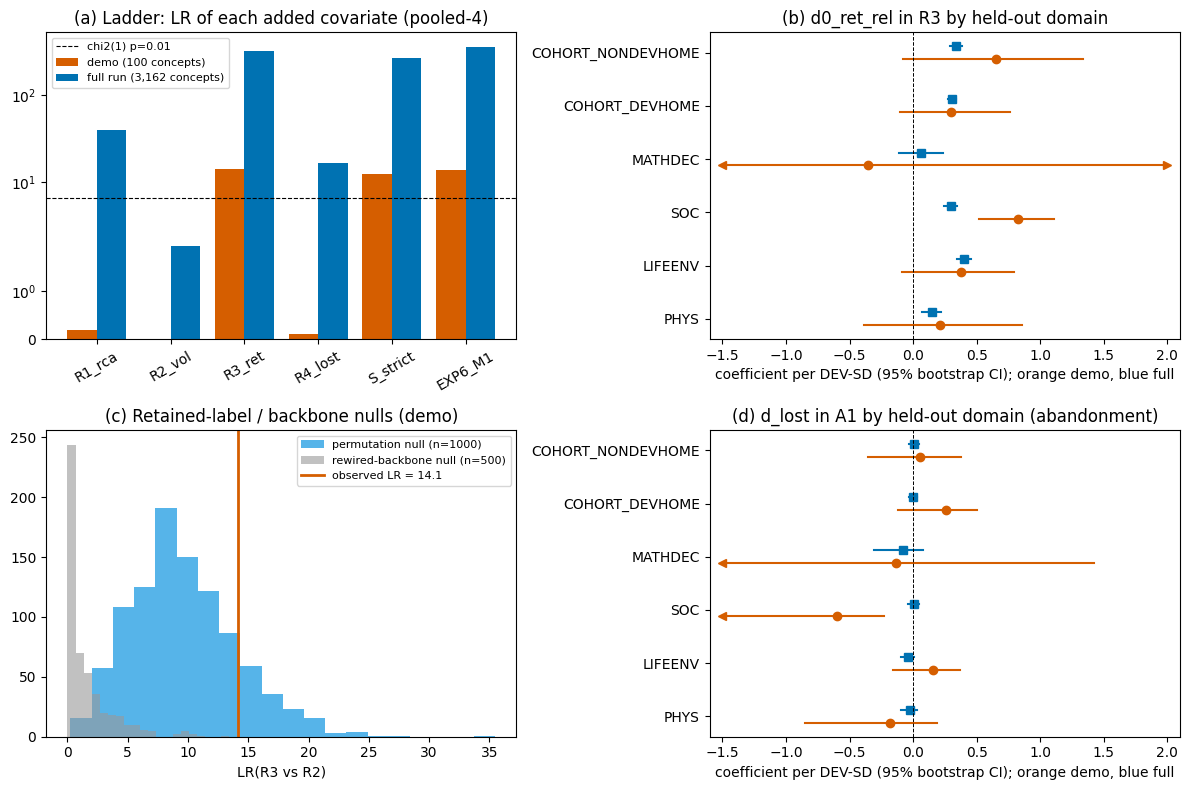

In [22]:
ho = json.loads((RES / "step2_heldout.json").read_text())
ref = data["metadata"]["full_scale_reference"]
lad = ho["pooled4"]["ladder"]["frontier_primary_sample"]
print("pooled-4 primary sample:", lad["n"])

# 1) ladder
tab = pd.DataFrame({"LR_demo": {k: v["LR"] for k, v in lad["LR"].items()},
                    "p_demo": {k: v["p"] for k, v in lad["LR"].items()},
                    "LR_full": ref["pooled4_ladder_LR"]})
print("\nLadder (LR of the added block):"); display(tab.round(3))
print("within-stratum AUC (demo | full):",
      {k: (round(v, 3), round(ref["pooled4_auc_within"].get(k, float("nan")), 3)) for k, v in lad["auc_within"].items() if k in ("R0_M0", "R2_vol", "R3_ret")})

# 2) headline numbers and verdicts
v, vf = ho["verdicts"], ref["verdicts"]
sp = ho["pooled4"]["specificity"]
head = pd.DataFrame({
    "demo": [v["d0_pooled4"], str(np.round(v["d0_ci"], 3)), v["d0_S_strict"], str(np.round(v["d0_S_strict_ci"], 3)),
             v["cohort_d0"], v["d_lost_pooled4"], str(np.round(v["d_lost_ci"], 3)), sp["a_permutation"]["p"],
             sp["d_backbone_d0_only"]["rewire"]["p"], sp["d_backbone_d0_only"]["label_perm"]["p"]],
    "full": [vf["d0_pooled4"], str(np.round(vf["d0_ci"], 3)), vf["d0_S_strict"], str(np.round(vf["d0_S_strict_ci"], 3)),
             vf["cohort_d0"], vf["d_lost_pooled4"], str(np.round(vf["d_lost_ci"], 3)), vf["holm"]["F2"]["raw"]["perm"],
             vf["holm"]["F2"]["raw"]["rewire"], vf["holm"]["F2"]["raw"]["label_perm"]]},
    index=["d0 in R3 (pooled-4)", "  bootstrap 95% CI", "d0 in S_strict", "  bootstrap 95% CI", "d0 in R3 (cohort)",
           "d_lost in A1", "  bootstrap 95% CI", "retained-label permutation p", "rewire null p", "node-label null p"])
display(head)
crit = pd.DataFrame({"demo": v["criteria"], "full": vf["criteria"]})
display(crit)
print("FRONTIER    demo:", v["FRONTIER"], "\n            full:", vf["FRONTIER"])
print("ABANDONMENT demo:", v["ABANDONMENT"], "\n            full:", vf["ABANDONMENT"])
vm = sp["b_volume_matched"]
print("volume-matched contrast (R - N), demo:", vm.get("contrast_R_minus_N", {}).get("est", vm.get("status")),
      vm.get("contrast_R_minus_N", {}).get("ci", ""))

# 3) figures
units = ["PHYS", "LIFEENV", "SOC", "MATHDEC", "COHORT_DEVHOME", "COHORT_NONDEVHOME"]
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
keys = ["R1_rca_vs_R0_M0", "R2_vol_vs_R1_rca", "R3_ret_vs_R2_vol", "R4_lost_vs_R3_ret", "S_strict_vs_S_strict0", "EXP6_M1_vs_R0_M0"]
x = np.arange(len(keys))
ax[0, 0].bar(x - 0.2, [lad["LR"][k]["LR"] for k in keys], 0.4, label="demo (100 concepts)", color="#D55E00")
ax[0, 0].bar(x + 0.2, [ref["pooled4_ladder_LR"][k] for k in keys], 0.4, label="full run (3,162 concepts)", color="#0072B2")
ax[0, 0].set_yscale("symlog"); ax[0, 0].set_xticks(x); ax[0, 0].set_xticklabels([k.split("_vs_")[0] for k in keys], rotation=30)
ax[0, 0].axhline(6.63, color="k", ls="--", lw=0.8, label="chi2(1) p=0.01"); ax[0, 0].legend(fontsize=8)
ax[0, 0].set_title("(a) Ladder: LR of each added covariate (pooled-4)")

def forest(a, key, refkey, title, lim=(-1.5, 2.0)):
    # CIs of tiny demo units (e.g. MATHDEC, 8 concepts) can run away under separation: clip to `lim`, arrow = clipped
    rows = [u for u in units if key in ho["units"].get(u, {})]
    for i, u in enumerate(rows):
        for d, dy, col, mk in ((ho["units"][u][key], -0.12, "#D55E00", "o"), (ref[refkey].get(u), 0.12, "#0072B2", "s")):
            if not d:
                continue
            lo, hi = np.clip(d["boot_ci"], *lim)
            a.plot([lo, hi], [i + dy] * 2, color=col); a.plot(np.clip(d["coef"], *lim), i + dy, mk, color=col)
            if d["boot_ci"][0] < lim[0]: a.plot(lim[0], i + dy, "<", color=col)
            if d["boot_ci"][1] > lim[1]: a.plot(lim[1], i + dy, ">", color=col)
    a.axvline(0, color="k", lw=0.7, ls="--"); a.set_yticks(range(len(rows))); a.set_yticklabels(rows)
    a.set_xlim(lim[0] - 0.1, lim[1] + 0.1)
    a.set_title(title); a.set_xlabel("coefficient per DEV-SD (95% bootstrap CI); orange demo, blue full")

forest(ax[0, 1], "d0_R3", "units_d0_R3", "(b) d0_ret_rel in R3 by held-out domain")
nz = np.load(RES / "nulls_exp5_heldout_pooled4.npz")
ax[1, 0].hist(nz["perm"], bins=20, color="#56B4E9", label=f"permutation null (n={len(nz['perm'])})")
ax[1, 0].hist(nz["rewire"], bins=20, color="#999999", alpha=0.6, label=f"rewired-backbone null (n={len(nz['rewire'])})")
ax[1, 0].axvline(float(nz["LR_obs"]), color="#D55E00", lw=2, label=f"observed LR = {float(nz['LR_obs']):.1f}")
ax[1, 0].set_xlabel("LR(R3 vs R2)"); ax[1, 0].legend(fontsize=8); ax[1, 0].set_title("(c) Retained-label / backbone nulls (demo)")
forest(ax[1, 1], "d_lost_A1", "units_d_lost_A1", "(d) d_lost in A1 by held-out domain (abandonment)")
plt.tight_layout(); plt.savefig(FIGS / "demo_summary.png", dpi=120); plt.show()

## Takeaways

* On 100 held-out concepts the retained-frontier covariate `d0_ret_rel` still adds clearly to the RCA>1 and share-weighted
  density rivals (LR(R3 vs R2) and LR(S_strict vs S_strict0) significant, positive `d0`, within-stratum AUC up from R2
  to R3), in line with the full run's `d0 = 0.32 [0.29, 0.36]`.
* The pre-declared **volume-matched contrast** (retained vs entered-not-retained fields with the same current x cumulative
  volume) is not distinguishable from zero, so the frozen rules give **FRONTIER = PARTIAL ("persistence confounded with
  volume")** here as in the full run. The abandonment penalty `d_lost` is **INCONCLUSIVE** in both.
* What the smaller sample loses is power: the retained-label permutation test (criterion 4) and the per-domain CIs need
  the full 3,162-concept held-out frame. To reproduce the full numbers, run the original repository
  (`method.py step1 / dev / freeze / heldout / outputs`) on the complete EXP5/EXP6 inputs.